# 00 以480m数据清理

In [30]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        if 'lst_ratio' in gdf.columns:
            before_count = len(gdf)
            gdf_clean = gdf[gdf['lst_ratio'] >= 0.8]
            after_count = len(gdf_clean)

            if before_count != after_count:
                output_path = os.path.join(output_folder, filename)
                gdf_clean.to_file(output_path)
                print(f"✔ 清理 {filename}：原始 {before_count} 行，清理后 {after_count} 行")


✔ 清理 city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 2245 行，清理后 1861 行
✔ 清理 city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 2148 行，清理后 1572 行


# 00 根据480m的有效范围去裁剪120m和240m

In [32]:
import os
import geopandas as gpd

# 工作路径与数据路径
work_space = r'D:\seoul\grids\lst_map\final_clean'
year = 2016
data_file_120 = os.path.join(work_space, f'city{year}_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')
data_file_240 = os.path.join(work_space, f'city{year}_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')
data_file_480 = os.path.join(work_space, r'480_based', f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')

output_space = os.path.join(work_space, '480_based')
os.makedirs(output_space, exist_ok=True)

def clean_file_by_within(input_file, base_file, output_file):
    gdf_input = gpd.read_file(input_file)
    gdf_base = gpd.read_file(base_file)

    # 确保投影一致
    if gdf_input.crs != gdf_base.crs:
        gdf_base = gdf_base.to_crs(gdf_input.crs)

    # 将 480m 网格合并为一个大的几何体集合
    base_union = gdf_base.unary_union
    gdf_filtered = gdf_input[gdf_input.geometry.buffer(-0.0001).within(base_union)]

    # # 判断每个小网格是否完全包含于480网格中
    # gdf_filtered = gdf_input[gdf_input.geometry.within(base_union)]

    # 保存输出
    gdf_filtered.to_file(output_file)
    print(f"✔ 完成清洗: {output_file}，保留 {len(gdf_filtered)} 个网格.")

# 输出路径定义
output_file_120 = os.path.join(output_space, os.path.basename(data_file_120))
output_file_240 = os.path.join(output_space, os.path.basename(data_file_240))

# 执行清洗
clean_file_by_within(data_file_120, data_file_480, output_file_120)
clean_file_by_within(data_file_240, data_file_480, output_file_240)


✔ 完成清洗: D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp，保留 29707 个网格.
✔ 完成清洗: D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp，保留 7442 个网格.


# 00 清理 120m 和 240m 的 lst_ratio <0.8

In [33]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        if 'lst_ratio' in gdf.columns:
            before_count = len(gdf)
            gdf_clean = gdf[gdf['lst_ratio'] >= 0.8]
            after_count = len(gdf_clean)

            if before_count != after_count:
                output_path = os.path.join(output_folder, filename)
                gdf_clean.to_file(output_path)
                print(f"✔ 清理 {filename}：原始 {before_count} 行，清理后 {after_count} 行")


✔ 清理 city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 29707 行，清理后 29283 行
✔ 清理 city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 7442 行，清理后 7338 行
✔ 清理 city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 25121 行，清理后 24306 行
✔ 清理 city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 6288 行，清理后 6093 行


# 00 需要清理掉2016和2023的孤岛点

In [ ]:
import geopandas as gpd
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
year =2016
file = fr"{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp"
islands = [1308, 1377, 1411, 1471, 1525, 1690]

gdf = gpd.read_file(file)
gdf_clean = gdf.drop(index=islands, errors="ignore").reset_index(drop=True)

output_file = file.replace(".shp", "_clean.shp")
gdf_clean.to_file(output_file)

print("Saved:", output_file)
import geopandas as gpd
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
year =2023
file = fr"{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp"
islands = [1392,1571]

gdf = gpd.read_file(file)
gdf_clean = gdf.drop(index=islands, errors="ignore").reset_index(drop=True)

output_file = file.replace(".shp", "_clean.shp")
gdf_clean.to_file(output_file)

print("Saved:", output_file)

# 00根据480的清理掉120和240的

In [4]:
import os
import geopandas as gpd

# 工作路径与数据路径
work_space = r'D:\seoul\grids\lst_map\final_clean'
year = 2016
year = 2023
data_file_120 = os.path.join(work_space, f'city{year}_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')
data_file_240 = os.path.join(work_space, f'city{year}_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')
data_file_480 = os.path.join(work_space, r'480_based', f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp')

output_space = os.path.join(work_space, '480_based')
os.makedirs(output_space, exist_ok=True)

def clean_file_by_within(input_file, base_file, output_file):
    gdf_input = gpd.read_file(input_file)
    gdf_base = gpd.read_file(base_file)

    # 确保投影一致
    if gdf_input.crs != gdf_base.crs:
        gdf_base = gdf_base.to_crs(gdf_input.crs)

    # 将 480m 网格合并为一个大的几何体集合
    base_union = gdf_base.unary_union
    gdf_filtered = gdf_input[gdf_input.geometry.buffer(-0.0001).within(base_union)]

    # # 判断每个小网格是否完全包含于480网格中
    # gdf_filtered = gdf_input[gdf_input.geometry.within(base_union)]

    # 保存输出
    gdf_filtered.to_file(output_file)
    print(f"✔ 完成清洗: {output_file}，保留 {len(gdf_filtered)} 个网格.")

def add_clean_suffix(filepath):
    name, ext = os.path.splitext(os.path.basename(filepath))
    return os.path.join(output_space, f"{name}_clean{ext}")

output_file_120 = add_clean_suffix(data_file_120)
output_file_240 = add_clean_suffix(data_file_240)


# 执行清洗
clean_file_by_within(data_file_120, data_file_480, output_file_120)
clean_file_by_within(data_file_240, data_file_480, output_file_240)

✔ 完成清洗: D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp，保留 25089 个网格.
✔ 完成清洗: D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp，保留 6280 个网格.


# 00 + M -> KM

In [58]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        # 标记是否有修改
        modified = False

        # 转换三个距离字段：米 → 公里
        for col in ['Dist_WB', 'Dist_BP', 'Dist_MT']:
            if col in gdf.columns:
                gdf[col] = gdf[col] / 1000.0
                modified = True

        if modified:
            output_path = os.path.join(output_folder, filename)
            gdf.to_file(output_path)
            print(f"✔ 已更新 {filename}：三个距离字段已转换为公里")
        else:
            print(f"ℹ️ 跳过 {filename}：未找到指定字段")


✔ 已更新 city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里


# 00 + 集体改名
explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                    'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_P', 'Dist_M', 'Dist_W']   

In [ ]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        # 改字段名
        gdf = gdf.rename(columns={
            'Dist_WB': 'Dist_W',
            'Dist_BP': 'Dist_P',
            'Dist_MT': 'Dist_M'
        })

        # 保存 shapefile
        output_path = os.path.join(output_folder, filename)
        gdf.to_file(output_path)

In [ ]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)


for filename in os.listdir(grid_folder):
    if filename.endswith('bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        # 改字段名
        gdf = gdf.rename(columns={
            'BCR(%)': 'BCR',
            'EV(m)': 'EV',
            'WR(%)': 'WR'
        })

        # 保存 shapefile
        output_path = os.path.join(output_folder, filename)
        gdf.to_file(output_path)

# 00 画一个新的区域范围图

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 首尔行政边界
shp_seoul = r'D:\seoul\Final_data\Admin_boundary\Seoul_boundary.shp'
gdf_seoul = gpd.read_file(shp_seoul)

# 输出文件夹
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\figures'
os.makedirs(output_folder, exist_ok=True)
grid_sizes = [120,240,480]
for year in [2016,2023]:

    for i in grid_sizes:
        shp_path = rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_{i}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'

        gdf = gpd.read_file(shp_path)

        # 如果两者 CRS 不一致，投影到相同坐标系
        if gdf.crs != gdf_seoul.crs:
            gdf_seoul = gdf_seoul.to_crs(gdf.crs)

        fig, ax = plt.subplots(figsize=(8, 8))
        # 再叠加边界线
        gdf_seoul.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
        # 先画格网
        gdf.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.3)

        ax.set_title(f'Grid Size: {i}m', fontsize=14)
        ax.axis('off')

        output_path = os.path.join(output_folder, f'{year}_grid_{i}m_gray.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved: {output_path}")

✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2016_grid_120m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2016_grid_240m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2016_grid_480m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2023_grid_120m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2023_grid_240m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2023_grid_480m_gray.png


# 00 基于480m的grid打标签FID_1 方便最后比较

In [35]:
years=[2016,2023]
for year in years:
    shp_path = rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    file_480= gpd.read_file(shp_path)
    file_480['FID_1'] = file_480.index
    file_480.to_file(shp_path)

In [36]:
import geopandas as gpd

def assign_fid_from_larger_grid(small_grid_path, large_grid_path, fid_field='FID_1'):
    """
    将较小网格的每个单元中心点匹配到较大网格中的FID，并写入原shapefile。

    Parameters:
        small_grid_path (str): 较小网格（如120m或240m）的Shapefile路径
        large_grid_path (str): 较大网格（如480m）的Shapefile路径，需包含FID字段
        fid_field (str): 在大网格中要匹配的字段名，默认是 'FID_1'
    """

    print(f"🔍 正在处理文件：{small_grid_path}")

    # 读取两个图层
    large_gdf = gpd.read_file(large_grid_path)
    small_gdf = gpd.read_file(small_grid_path)

    # 确保投影一致
    large_gdf = large_gdf.to_crs(small_gdf.crs)

    # 计算小网格中心点
    small_gdf['centroid'] = small_gdf.geometry.centroid
    centroids = gpd.GeoDataFrame(small_gdf[['centroid']], geometry='centroid', crs=small_gdf.crs)

    # 执行空间连接：中心点 within 大网格
    joined = gpd.sjoin(centroids, large_gdf[[fid_field, 'geometry']], how='left', predicate='within')

    # 将FID字段赋值给原始数据
    small_gdf[fid_field] = joined[fid_field].values

    # 删除中间计算列
    small_gdf = small_gdf.drop(columns='centroid')

    # 保存回原始路径
    small_gdf.to_file(small_grid_path)
    print(f"✔ 完成并保存：{small_grid_path}\n")

for year in [2016,2023]:
    for grid in [120,240]:
        assign_fid_from_larger_grid(
            small_grid_path=rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_{grid}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp',
            large_grid_path=rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        )



🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp

🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp

🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp

🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2023_

# 00 画一下各个参数的图

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import numpy as np
from mapclassify import NaturalBreaks

# 输出文件夹
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored'
os.makedirs(output_folder, exist_ok=True)
seoul_boundary_file = r'D:\seoul\c_data\Admin_boundary\Seoul_boundary.shp'

# 网格大小
grid_sizes = [120, 240, 480]

# 自动投影到韩国 UTM zone 52N（EPSG:32652）保证比例真实
target_crs = 'EPSG:32652'

for year in [2016, 2023]:
    explanatory_vars = [f'ext_{year}', f'nor_{year}', f'hr_{year}',
                        'BCR(%)', 'BHA', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    explanatory_vars_visual = [f'extreme', f'normal', f'HR',
                               'BCR', 'BHA', 'BHV', 'NDVI', 'SVF', 'EV',
                               'Dist_P', 'Dist_M', 'Dist_W', 'WR']

    for value_column, name in zip(explanatory_vars, explanatory_vars_visual):
        for i in grid_sizes:
            shp_path = rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_{i}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'

            if not os.path.exists(shp_path):
                print(f"❌ 文件不存在：{shp_path}")
                continue

            gdf = gpd.read_file(shp_path)
            boundary = gpd.read_file(seoul_boundary_file)

            # 投影到目标 CRS（UTM zone 52N）
            if gdf.crs != target_crs:
                gdf = gdf.to_crs(target_crs)
            if boundary.crs != target_crs:
                boundary = boundary.to_crs(target_crs)

            # 创建分级分类器
            classifier = NaturalBreaks(gdf[value_column], k=5)
            bins = classifier.bins
            gdf['class'] = classifier.yb  # 分类索引

            # 色带
            cmap = plt.get_cmap('RdYlBu_r')
            colors = cmap(np.linspace(0, 1, 5))

            # 绘图
            fig, ax = plt.subplots(figsize=(9, 8))
            boundary.plot(ax=ax, color='white', edgecolor='black', linewidth=1.0, zorder=0)

            for cls in range(5):
                gdf[gdf['class'] == cls].plot(ax=ax, color=colors[cls], linewidth=0.2, edgecolor='gray', zorder=1)

            # ax.set_title(f'{year} {name} (Grid: {i}m)', fontsize=14)
            ax.axis('off')

            # 构建 legend
            patches = []
            for j in range(5):
                if j == 0:
                    label = f'≤ {bins[j]:.2f}'
                else:
                    label = f'{bins[j-1]:.2f} - {bins[j]:.2f}'
                patch = mpatches.Patch(color=colors[j], label=label)
                patches.append(patch)

            ax.legend(handles=patches,
                      title=name,
                      loc='upper left',
                      bbox_to_anchor=(0.85, 0.95),
                      frameon=True)

            # 保存图像
            output_path = os.path.join(output_folder, f'{year}_{name}_{i}m_map.png')
            fig.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
            plt.savefig(output_path, dpi=300)
            plt.close()
            print(f"✅ Saved: {output_path}")


✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_extreme_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_extreme_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_extreme_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_normal_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_normal_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_normal_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_HR_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_HR_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_HR_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_BCR (%)_120m_map.pn

# 00 Descriptive statistics

In [5]:
import os
import re
import pandas as pd
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = os.path.join(grid_folder, r'statistics')
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
        input_path = os.path.join(grid_folder, filename)
        data = gpd.read_file(input_path)

for year in [2016, 2023]:
    output_path = os.path.join(output_folder, f'{year} Descriptive statistics.xlsx')
    all_stats = []
    
    for filename in os.listdir(grid_folder):
        if filename.endswith('_xy.shp') and filename.startswith(f'city{year}'):
            input_path = os.path.join(grid_folder, filename)
            df = gpd.read_file(input_path)

            raw_columns = [f'nor_{year}', f'ext_{year}', f'hr_{year}', 'BHV', 'BCR', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_P', 'Dist_W', 'Dist_M']
            output_labels = ['Normal_LST', 'Extreme_LST', 'HR_LST', 'BHV', 'BCR', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_P', 'Dist_W', 'Dist_M']

            desc = df[raw_columns].describe().T[['mean', 'min', 'max', 'std']]
            desc.columns = ['Mean', 'Min', 'Max', 'SD']
            desc.index = output_labels
            desc = desc.round(2)

            # ✅ 提取 grid ID
            match = re.search(r'(\d{3,5})m', filename)
            grid_id = match.group(1) if match else 'Unknown'

            desc['Grid'] = grid_id

            # ✅ 添加观测值（每个 grid 有多少行）
            desc['N'] = len(df)

            all_stats.append(desc.reset_index())

    # 合并所有 grid 的结果
    summary_df = pd.concat(all_stats, ignore_index=True)
    summary_df.rename(columns={'index': 'Variable'}, inplace=True)

    # 输出 Excel
    summary_df.to_excel(output_path, index=False)
    print(f"📁 描述性统计合并完成！保存路径：{output_path}")


📁 描述性统计合并完成！保存路径：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2016 Descriptive statistics.xlsx
📁 描述性统计合并完成！保存路径：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2023 Descriptive statistics.xlsx


# 01 spatial regression model

## 00 feature correlation test, find out whether or not there has multicollinearity,用pearson, spearman还有传统VIF

① Pearson 相关系数（皮尔逊相关）
用于连续型变量之间的线性相关性检验。
范围：-1 到 1，越接近 ±1 说明线性关系越强。
适用：变量呈正态分布时。
from scipy.stats import pearsonr
r, p = pearsonr(x, y)

<!-- ② Spearman 等级相关系数（斯皮尔曼相关）-- 在我们的研究中适用
用于连续或顺序变量之间的单调关系检验，不要求正态分布。
适用：非正态分布或有异常值时更稳健。
from scipy.stats import spearmanr
rho, p = spearmanr(x, y) -->

③ VIF（方差膨胀因子，Variance Inflation Factor）
用于检测自变量之间的多重共线性。
规则：VIF > 10（或 5）表示严重共线性，需剔除相关变量。
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = variance_inflation_factor(X.values, i)

<!-- 比较出问题之后,剔除了BHA -->

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import ListedColormap

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

# 自定义阈值颜色
colors = ["#eeeeee", "#ffcc99", "#ff6666"]  # 低-中-高相关
cmap = ListedColormap(colors)

# 分类函数
def categorize_corr(r):
    r_abs = abs(r)
    if r_abs < 0.4:
        return 0
    elif r_abs < 0.8:
        return 1
    else:
        return 2

for year in [2016, 2023]:
    explanatory_vars = ['BCR', 'BHA', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            df = gdf[explanatory_vars].dropna()

            # ----------------- 相关性 -----------------
            pearson_corr = df.corr(method='pearson')
            spearman_corr = df.corr(method='spearman')

            # 分类矩阵
            pearson_cat = pearson_corr.applymap(categorize_corr)
            spearman_cat = spearman_corr.applymap(categorize_corr)

            mask = np.triu(np.ones_like(pearson_corr, dtype=bool))  # 上三角遮掉

            # --- Pearson ---
            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(
                pearson_cat,
                annot=pearson_corr.round(2),
                fmt=".2f",
                cmap=cmap,
                ax=ax,
                mask=mask,
                cbar_kws={"ticks": [0.33, 1, 1.66], "label": "Correlation Level"}
            )
            plt.title(f"Pearson Correlation Matrix ({year})\nThresholds: 0.4 (moderate), 0.8 (high)")
            plt.tight_layout()
            save_path = os.path.join(grid_folder, r'statistics\fig\variable_correlation', f"{year}_pearson_corr.png")
            plt.savefig(save_path)
            plt.close()

            # --- Spearman ---
            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(
                spearman_cat,
                annot=spearman_corr.round(2),
                fmt=".2f",
                cmap=cmap,
                ax=ax,
                mask=mask,
                cbar_kws={"ticks": [0.33, 1, 1.66], "label": "Correlation Level"}
            )
            plt.title(f"Spearman Correlation Matrix ({year})\nThresholds: 0.4 (moderate), 0.8 (high)")
            plt.tight_layout()
            save_path = os.path.join(grid_folder, r'statistics\fig\variable_correlation', f"{year}_spearman_corr_cat.png")
            plt.savefig(save_path)
            plt.close()

            # ----------------- VIF -----------------
            df_vif = df.copy()
            df_vif["Intercept"] = 1
            vif_df = pd.DataFrame()
            vif_df["Variable"] = df_vif.columns
            vif_df["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
            vif_df = vif_df[vif_df["Variable"] != "Intercept"]

            vif_path = os.path.join(grid_folder, r'statistics\fig\variable_correlation', f"{year}_VIF.xlsx")
            vif_df.to_excel(vif_path, index=False)

            print(f"✅ 变量相关性分析完成：{year}")


C:\Users\owner\AppData\Local\Temp\ipykernel_36360\3089063064.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pearson_cat = pearson_corr.applymap(categorize_corr)
C:\Users\owner\AppData\Local\Temp\ipykernel_36360\3089063064.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  spearman_cat = spearman_corr.applymap(categorize_corr)


✅ 变量相关性分析完成：2016


C:\Users\owner\AppData\Local\Temp\ipykernel_36360\3089063064.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pearson_cat = pearson_corr.applymap(categorize_corr)
C:\Users\owner\AppData\Local\Temp\ipykernel_36360\3089063064.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  spearman_cat = spearman_corr.applymap(categorize_corr)


✅ 变量相关性分析完成：2023


## 01 OLS regression models.

首先使用普通最小二乘法（Ordinary Least Squares, OLS）建立基础回归模型。
评估模型解释力和残差行为。

In [7]:
import os
import geopandas as gpd
import statsmodels.api as sm
import re
import numpy as np
from spreg import OLS, LMtests

# 📁 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'


for year in [2016,2023]:

    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']    # 顺序很讲究
    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp') and filename.startswith(f'city{year}'):
            filepath = os.path.join(grid_folder, filename)
            print(f"Processing {filename}...")

            # 读取 shapefile
            gdf = gpd.read_file(filepath)

            for target in target_vars:
                y = gdf[target]
                X = gdf[explanatory_vars]
                '''
                y = β₁X₁ + β₂X₂ + ...
                '''
                X = sm.add_constant(X)  # 添加截距项
                ''' -> 截距的意思是
                y = β₁X₁ + β₂X₂ + ...+ ε
                '''

                model = sm.OLS(y, X)
                results = model.fit()

                # 提取文件名中的 3~5 位数字
                match = re.search(r'grid_(\d{3,5})m', filename)
                file_id = match.group() if match else "Unknown"

                print(f"OLS results for {file_id} | target: {target}")
                #print(results.summary())

                print(f"R²: {results.rsquared:.4f}")
                rmse = np.sqrt(np.mean(results.resid ** 2))
                print(f"RMSE: {rmse:.4f}")

Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp...
OLS results for grid_480m | target: nor_2016
R²: 0.8541
RMSE: 0.9575
OLS results for grid_480m | target: ext_2016
R²: 0.9066
RMSE: 1.2352
OLS results for grid_480m | target: hr_2016
R²: 0.8131
RMSE: 0.7700
Processing city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp...
OLS results for grid_480m | target: nor_2023
R²: 0.9206
RMSE: 1.1585
OLS results for grid_480m | target: ext_2023
R²: 0.8627
RMSE: 1.6217
OLS results for grid_480m | target: hr_2023
R²: 0.1300
RMSE: 1.2969


In [8]:
#数据自身的统计情况
# import geopandas as gpd
# import rasterio
# import numpy as np
# from rasterio.mask import mask
# import pandas as pd
# import os

# # ------------------- 公共函数 -------------------
# def raster_stats(raster_path, shapes):
#     with rasterio.open(raster_path) as src:
#         shapes = shapes.to_crs(src.crs)
#         try:
#             out_image, _ = mask(src, shapes.geometry, crop=True)
#         except ValueError:
#             return np.nan, np.nan, np.nan, np.nan  # 完全不重叠

#         data = out_image[0]
#         data = data[data != src.nodata]
#         if len(data) == 0:
#             return np.nan, np.nan, np.nan, np.nan
#         return data.mean(), data.min(), data.max(), data.std()

# def single_val_stats(val):
#     return val, np.nan, np.nan, np.nan

# def coverage_ratio(feature_gdf, valid_gdf, grid_area):
#     valid_gdf = valid_gdf.to_crs(feature_gdf.crs)
#     inside_feature = gpd.overlay(feature_gdf, valid_gdf, how='intersection')
#     return (inside_feature.geometry.area.sum() / grid_area) * 100

# # ------------------- 主函数 -------------------
# def calculate_summary(year,
#                       shp_valid_path,
#                       building_path,
#                       ndvi_path,
#                       svf_path,
#                       elevation_path,
#                       normal_path,
#                       extreme_path,
#                       hr_path,
#                       water_path,
#                       output_folder):

#     # --- shapefile ---
#     valid_gdf = gpd.read_file(shp_valid_path)
#     building_gdf = gpd.read_file(building_path)
#     water_gdf = gpd.read_file(water_path)

#     # --- 建筑物 ---
#     valid_gdf = valid_gdf.to_crs(building_gdf.crs)
#     inside_building = gpd.overlay(building_gdf, valid_gdf, how='intersection')

#     if 'area' not in inside_building.columns:
#         inside_building['area'] = inside_building.geometry.area

#     total_bldg_area = inside_building['area'].sum()
#     height_std = inside_building['height'].std()
#     height_std = 0 if np.isnan(height_std) else height_std
#     grid_area = valid_gdf.geometry.area.sum()
#     bcr = (total_bldg_area / grid_area) * 100
#     water_ratio = coverage_ratio(water_gdf, valid_gdf, grid_area)

#     # --- 栅格 ---
#     ndvi_stats = raster_stats(ndvi_path, valid_gdf)
#     svf_stats = raster_stats(svf_path, valid_gdf)
#     dem_stats = raster_stats(elevation_path, valid_gdf)
#     normalheat_stats = raster_stats(normal_path, valid_gdf)
#     extremeheat_stats = raster_stats(extreme_path, valid_gdf)
#     hr_stats = raster_stats(hr_path, valid_gdf)

#     # --- 单值 ---
#     bcr_stats = single_val_stats(bcr)
#     bhv_stats = single_val_stats(height_std)
#     wr_stats = single_val_stats(water_ratio)

#     # --- 构建 summary ---
#     summary_values = [
#         *normalheat_stats,
#         *extremeheat_stats,
#         *hr_stats,
#         *bhv_stats,
#         *bcr_stats,
#         *svf_stats,
#         *ndvi_stats,
#         *dem_stats,
#         *wr_stats
#     ]

#     metrics = [
#         "Normal_LST", "Extreme_LST", "HR_T", "BHV", "BCR(%)", 
#         "SVF", "NDVI", "EV", "WR(%)"
#     ]

#     rows = []
#     for i, metric in enumerate(metrics):
#         start = i * 4
#         stats_group = summary_values[start:start+4]
#         rows.append([metric, *stats_group])

#     summary_matrix = pd.DataFrame(
#         rows,
#         columns=["Indicator", "Mean", "Min", "Max", "Std"]
#     )

#     # --- 保存 ---
#     os.makedirs(output_folder, exist_ok=True)
#     output_file = os.path.join(output_folder, f"seoul_{year}_summary.xlsx")
#     summary_matrix.to_excel(output_file, index=False)

#     print(f"\n====== {year} Summary Statistics (Grouped) ======")
#     print(summary_matrix.to_string(index=False))
#     print(f"\n✅ 已保存到 {output_file}")
#     return summary_matrix


# # 
# calculate_summary(
#     2016,
#     shp_valid_path=r"D:\seoul\grids\lst_map\final_clean\480_based\valid_2016_grid_480m.shp",
#     building_path=r"D:\seoul\c_data\a_building\final\Fin_building.shp",
#     ndvi_path=r"D:\seoul\c_data\b_ndvi\d_clean\clipped_ndvi_20160924_cleaned.tif",
#     svf_path=r"D:\seoul\c_data\c_svf\final_svf.tif",
#     elevation_path=r"D:\seoul\c_data\d_elevation\seoul_dem.tif",
#     normal_path=r"D:\seoul\b_satellite_img\normal_heat_day_lst\clipped_20160924_B10_cleaned_LST.tif",
#     extreme_path=r"D:\seoul\b_satellite_img\extreme_heat_day_lst\clipped_20160807_B10_cleaned_LST.tif",
#     hr_path=r"D:\seoul\b_satellite_img\heat_resilience\2016_heat_resilience.tif",
#     water_path=r"D:\seoul\c_data\g_stream\seoul_stream_final.shp",
#     output_folder=r"D:\seoul\grids\lst_map\final_clean\480_based\statistics\original data statistics"
# )

# calculate_summary(
#     2023,
#     shp_valid_path=r"D:\seoul\grids\lst_map\final_clean\480_based\valid_2023_grid_480m.shp",
#     building_path=r"D:\seoul\c_data\a_building\final\Fin_building.shp",
#     ndvi_path=r"D:\seoul\c_data\b_ndvi\d_clean\clipped_ndvi_20230616_cleaned.tif",
#     svf_path=r"D:\seoul\c_data\c_svf\final_svf.tif",
#     elevation_path=r"D:\seoul\c_data\d_elevation\seoul_dem.tif",
#     normal_path=r"D:\seoul\b_satellite_img\normal_heat_day_lst\clipped_20230616_B10_cleaned_LST.tif",
#     extreme_path=r"D:\seoul\b_satellite_img\extreme_heat_day_lst\clipped_20230819_B10_cleaned_LST.tif",
#     hr_path=r"D:\seoul\b_satellite_img\heat_resilience\2023_heat_resilience.tif",
#     water_path=r"D:\seoul\c_data\g_stream\seoul_stream_final.shp",
#     output_folder=r"D:\seoul\grids\lst_map\final_clean\480_based\statistics\original data statistics"
# )

## 02 Moran’s I statistics:Test for Spatial Autocorrelation

使用 Moran’s I 统计量对 OLS 残差进行空间自相关检验。
若结果显著，说明存在空间自相关，OLS 模型不适用，需考虑空间回归模型。

In [ ]:
# ! python.exe -m pip install --upgrade pip
# ! {sys.executable} -m pip install libpysal==4.6.0

4.13.0


In [9]:
import os
import geopandas as gpd
import numpy as np
from esda.moran import Moran
from libpysal.weights import Queen
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import connected_components

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']    # 顺序很讲究
    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp') and filename.startswith(f'city{year}'):
            filepath = os.path.join(grid_folder, filename)
            print(f"\n📂 Processing {filename}...")

            gdf = gpd.read_file(filepath)
        
            for target in target_vars:
                print(f"\n🔍 Analyzing variable: {target}")

                # 构建空间权重并移除孤岛
                w = Queen.from_dataframe(gdf, use_index=False)
                islands = [i for i, neighbors in w.neighbors.items() if len(neighbors) == 0]

                gdf_clean = gdf.drop(index=islands).reset_index(drop=True)
                # 构建权重矩阵
                w_clean = Queen.from_dataframe(gdf_clean, use_index=False)

                # 转为邻接矩阵
                adj_matrix = w_clean.full()[0]

                # 识别连通分量
                n_components, labels = connected_components(csgraph=adj_matrix, directed=False)

                # 找出最大连通分量的标签
                largest_label = np.bincount(labels).argmax()

                # 找出对应索引
                main_component = np.where(labels == largest_label)[0]

                # 筛选最大连通子图
                gdf_main = gdf_clean.iloc[main_component].reset_index(drop=True)

                # 重建空间权重矩阵
                w_main = Queen.from_dataframe(gdf_main, use_index=False)
                w_main.transform = 'r'

                y = gdf_main[target]

                # 计算 Moran's I
                moran = Moran(y, w_main)
        
                print(f"Moran's I: {moran.I:.4f}")
                print(f"p-value: {moran.p_sim:.4f}")
                print(f"Expected I: {moran.EI:.4f}")
                print(f"Variance: {moran.VI_sim:.4f}")

                if moran.p_sim < 0.05:
                    print(f"'{year}✅ Significant spatial autocorrelation detected.")
                else:
                    print("❌ No significant spatial autocorrelation detected.")
                


📂 Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp...

🔍 Analyzing variable: nor_2016


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.6881
p-value: 0.0010
Expected I: -0.0006
Variance: 0.0002
'2016✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: ext_2016


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.6760
p-value: 0.0010
Expected I: -0.0006
Variance: 0.0001
'2016✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: hr_2016


...

Moran's I: 0.6775
p-value: 0.0010
Expected I: -0.0007
Variance: 0.0002
'2023✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: ext_2023


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.7007
p-value: 0.0010
Expected I: -0.0007
Variance: 0.0002
'2023✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: hr_2023


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.8606
p-value: 0.0010
Expected I: -0.0007
Variance: 0.0002
'2023✅ Significant spatial autocorrelation detected.


## 03 LM Test: Identify the Type of Spatial Dependence
使用 Lagrange Multiplier（LM）检验 判断空间依赖类型：
* LM-Lag（滞后型）：是否存在因变量的空间滞后项。
* LM-Error（误差型）：是否存在误差项的空间相关性。
* 同时参考 Robust LM-Lag 和 Robust LM-Error（控制另一种依赖类型后的检验）。
* 如果两个 Robust LM 检验都显著，说明两种依赖都可能存在，建议使用更一般形式的模型，如 SDM。

仅 LM-Error 显著	SEM（空间误差模型）
仅 LM-Lag 显著	SLM（空间滞后模型）
二者都显著	SDM（空间Durbin模型） 或进行进一步LR检验对比
SDM 是最一般的模型，可以退化为 SLM 或 SEM。
若 SDM 中某些系数不显著，可考虑退化为简化模型。

In [ ]:
import os
import numpy as np
import geopandas as gpd
import libpysal
from spreg import OLS, LMtests

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV',
                        'Dist_P', 'Dist_M', 'Dist_W', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp') and filename.startswith(f'city{year}'):
            filepath = os.path.join(grid_folder, filename)
            print(f"\nProcessing file: {filename}")

            gdf = gpd.read_file(filepath)
            w = libpysal.weights.Queen.from_dataframe(gdf, use_index=False)
            w.transform = 'r'

            for target in target_vars:
                print(f"\n→ Target variable: {target}")

                y = gdf[target].values.reshape(-1, 1)  # 变成二维数组
                X = gdf[explanatory_vars].values
                X = np.hstack((np.ones((X.shape[0], 1)), X))  # 添加常数项

                model = OLS(y, X, w=w, spat_diag=True, name_y=target, name_x=['const'] + explanatory_vars)
                
                # LMtests需要的是spreg的OLS结果，直接从model拿
                lms = LMtests(model, w)
                print(dir(lms))

                print(f"  LM-Lag (lml)                   : {lms.lml[0]:.4f}, p-value = {lms.lml[1]:.4g}")
                print(f"  LM-Error (lme)                 : {lms.lme[0]:.4f}, p-value = {lms.lme[1]:.4g}")
                print(f"  Robust LM-Lag (rlml)           : {lms.rlml[0]:.4f}, p-value = {lms.rlml[1]:.4g}")
                print(f"  Robust LM-Error (rlme)         : {lms.rlme[0]:.4f}, p-value = {lms.rlme[1]:.4g}")


Processing file: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)



→ Target variable: nor_2016
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'lme', 'lml', 'lmslxerr', 'lmspdurbin', 'lmwx', 'rlmdurlag', 'rlme', 'rlml', 'rlmwx', 'sarma']
  LM-Lag (lml)                   : 724.4704, p-value = 1.428e-159
  LM-Error (lme)                 : 1654.9462, p-value = 0
  Robust LM-Lag (rlml)           : 40.6684, p-value = 1.804e-10
  Robust LM-Error (rlme)         : 971.1442, p-value = 3.362e-213

→ Target variable: ext_2016
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', 

c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


## 04 LR Tests: Likelihood Ratio
在模型之间进行似然比检验（Likelihood Ratio Test），判断引入空间项后模型改进是否显著。

In [13]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import libpysal
from spreg import OLS, ML_Lag, ML_Error
from spreg.diagnostics import likratiotest
import time
from scipy.stats import chi2

# 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

# 初始化 DataFrame 保存结果
lr_results = pd.DataFrame(columns=[
    'Year', 'City', 'Dependent', 'Test', 'LR_stat', 'df', 'p_value'
])
model_info = pd.DataFrame(columns=[
    'Year', 'City', 'Dependent', 'Model', 'Variable', 'Coef', 'Std_err', 't_stat', 'p_value', 'R2', 'Adj_R2', 'Rho'
])

# 循环年份
for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV',
                        'Dist_P', 'Dist_M', 'Dist_W', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            print(f"\nProcessing {filename}")
            gdf = gpd.read_file(path)

            # 构造空间权重矩阵（1000米阈值距离）
            threshold = 1000
            w = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=False)
            w.transform = 'r'

            # 构造 y, X
            X0 = gdf[explanatory_vars].values
            x = np.hstack([np.ones((len(gdf), 1)), X0])  # 加常数列

            city_name = filename.split('_')[0]
            w_name = 'W1000'
            ds_name = f'yr{year}'

            for target in target_vars:
                yi = gdf[[target]].values
                models = {}

                # 1. OLS
                models['OLS'] = OLS(yi, x, w=w, spat_diag=True, moran=True,
                                    name_w=w_name, name_ds=ds_name)
                # SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1, spat_diag=True, moran=True,
                 name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1,
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1, method="full",
                    name_w=w_name, name_ds=ds_name)


                # 保存模型系数信息
                for mdl_name, mdl in models.items():
                    coef = mdl.betas.flatten()
                    var_names = ['const'] + explanatory_vars
                    if mdl_name in ['SLM', 'SDM']:
                        var_names += [f"W_{v}" for v in explanatory_vars]
                    if mdl_name == 'SDEM':
                        var_names += [f"W_{v}" for v in explanatory_vars]  # SDEM Durbin
                    se = mdl.std_err.flatten()
                    t_stat = coef / se
                    p_val = 2 * (1 - chi2.cdf(t_stat**2, 1))
                    R2 = getattr(mdl, 'r2', np.nan)
                    R2_adj = getattr(mdl, 'ar2', np.nan)
                    Rho = getattr(mdl, 'rho', np.nan)
                    if mdl_name in ['SEM', 'SDEM']:
                        Rho = getattr(mdl, 'lambda', np.nan)

                    for c, v, s, t, p in zip(coef, var_names, se, t_stat, p_val):
                        model_info = pd.concat([model_info, pd.DataFrame([{
                            'Year': year,
                            'City': city_name,
                            'Dependent': target,
                            'Model': mdl_name,
                            'Variable': v,
                            'Coef': c,
                            'Std_err': s,
                            't_stat': t,
                            'p_value': p,
                            'R2': R2,
                            'Adj_R2': R2_adj,
                            'Rho': Rho
                        }])], ignore_index=True)
                def safe_likratiotest(m0, m1):
                    res = likratiotest(m0, m1)
                    df_expected = len(m1.betas.flatten()) - len(m0.betas.flatten())
                    if res['df'] != df_expected:
                        print(f"⚠️ df mismatch: likratiotest={res['df']}, expected={df_expected}")
                        res['df'] = df_expected
                    return res
                # 提取 LR 检验
                lr_tests = {
                    'SLX-OLS': safe_likratiotest(models['OLS'], models['SLX']),
                    'SLM-OLS': safe_likratiotest(models['OLS'], models['SLM']),
                    'SDM-OLS': safe_likratiotest(models['OLS'], models['SDM']),
                    'SEM-OLS': safe_likratiotest(models['OLS'], models['SEM']),
                    'SDM-SLX': safe_likratiotest(models['SLX'], models['SDM']),
                    'SDM-SLM': safe_likratiotest(models['SLM'], models['SDM']),
                    'SDM-SEM': safe_likratiotest(models['SEM'], models['SDM']),
                    'SDEM-SLX': safe_likratiotest(models['SLX'], models['SDEM']),
                    'SDEM-SEM': safe_likratiotest(models['SEM'], models['SDEM']),
                }

                for test_name, res in lr_tests.items():
                    lr_results = pd.concat([lr_results, pd.DataFrame([{
                        'Year': year,
                        'City': city_name,
                        'Dependent': target,
                        'Test': test_name,
                        'LR_stat': res['likr'],
                        'df': res['df'],
                        'p_value': res['p-value']
                    }])], ignore_index=True)
                    print(f"{test_name}: df(likratiotest)={res['df']}, "
                            f"params_m0={len(models[test_name.split('-')[0]].betas.flatten())}, "
                            f"params_m1={len(models[test_name.split('-')[1]].betas.flatten())}")



# 保存 Excel
output_path = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\LR_test_results.xlsx'
with pd.ExcelWriter(output_path) as writer:
    lr_results.to_excel(writer, sheet_name='LR_tests', index=False)
    model_info.to_excel(writer, sheet_name='Model_info', index=False)


print(f"All LR test results and model info saved to {output_path}")


Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
C:\Us

⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


...

⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
All LR test results and model info saved to D:\seoul\grids\lst_map\final_clean\480_based\statistics\LR_test_results.xlsx


## 05 AIC & BIC analysis: 比较parital SEM & SDM

In [ ]:
# # 这个代码是在测试binary = True 和 False的区别
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# from shapely.geometry import Point
# import libpysal

# # ===== 1) 构造一个小测试数据（5个点，单位：米）=====
# # 如果你有真实 data_gdf（且是投影到米），直接用：
# # data_gdf = your_gdf.to_crs(XXXX)
# coords = [
#     (0, 0),
#     (300, 0),
#     (800, 0),
#     (0, 900),
#     (1200, 0),
# ]
# gdf = gpd.GeoDataFrame(geometry=[Point(xy) for xy in coords], crs="EPSG:5186")  # 例子用米制CRS

# threshold = 1000  # 1000米邻居阈值

# # ===== 2) 生成两种权重：binary 等权 vs 非 binary 衰减 =====
# w_bin = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=True)
# w_bin.transform = 'r'  # 行标准化

# w_ker = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=False)
# w_ker.transform = 'r'  # 行标准化 + 衰减信息保留

# # ===== 3) 打印前几行邻居列表和权重 =====
# def peek_weights(w, name, n_show=5):
#     print(f"\n=== {name} ===")
#     ids = list(w.neighbors.keys())[:n_show]
#     for i in ids:
#         neigh = w.neighbors[i]
#         weights = w.weights[i]
#         print(f"id {i} -> neighbors {neigh} ; weights {np.round(weights, 4)} ; row-sum={sum(weights):.2f}")

# peek_weights(w_bin, "Binary=True (等权, 行标准化后每个邻居权重≈1/度)")
# peek_weights(w_ker, "Binary=False (1/距离衰减, 行标准化后近邻更重)")

# # ===== 4) 可选：把稀疏矩阵导出查看 =====
# def weights_to_edges_df(w):
#     rows = []
#     for i, neighs in w.neighbors.items():
#         for j, wij in zip(neighs, w.weights[i]):
#             rows.append({"i": i, "j": j, "w_ij": wij})
#     return pd.DataFrame(rows)

# edges_bin = weights_to_edges_df(w_bin)
# edges_ker = weights_to_edges_df(w_ker)

# print(edges_bin)
# print(edges_ker)



=== Binary=True (等权, 行标准化后每个邻居权重≈1/度) ===
id 0 -> neighbors [1, 2, 3] ; weights [0.3333 0.3333 0.3333] ; row-sum=1.00
id 1 -> neighbors [0, 2, 3, 4] ; weights [0.25 0.25 0.25 0.25] ; row-sum=1.00
id 2 -> neighbors [0, 1, 4] ; weights [0.3333 0.3333 0.3333] ; row-sum=1.00
id 3 -> neighbors [0, 1] ; weights [0.5 0.5] ; row-sum=1.00
id 4 -> neighbors [1, 2] ; weights [0.5 0.5] ; row-sum=1.00

=== Binary=False (1/距离衰减, 行标准化后近邻更重) ===
id 0 -> neighbors [1, 2, 3] ; weights [0.5854 0.2195 0.1951] ; row-sum=1.00
id 1 -> neighbors [0, 2, 3, 4] ; weights [0.4445 0.2667 0.1406 0.1482] ; row-sum=1.00
id 2 -> neighbors [0, 1, 4] ; weights [0.2174 0.3478 0.4348] ; row-sum=1.00
id 3 -> neighbors [0, 1] ; weights [0.5132 0.4868] ; row-sum=1.00
id 4 -> neighbors [1, 2] ; weights [0.3077 0.6923] ; row-sum=1.00
    i  j      w_ij
0   0  1  0.333333
1   0  2  0.333333
2   0  3  0.333333
3   1  0  0.250000
4   1  2  0.250000
5   1  3  0.250000
6   1  4  0.250000
7   2  0  0.333333
8   2  1  0.333333
9   2

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag, OLS
# ML_Error_Het

# 设置路径
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

results_list = []
def show_formula(model):
    # yongl
    coefs = model.betas.flatten()
    vars_ = model.name_x
    formula = f"{model.name_y[0]} = "
    terms = [f"{coef:.4f}*{var}" for coef, var in zip(coefs, vars_)]
    
    # 添加空间参数
    if hasattr(model, "rho"):
        terms.append(f"{model.rho:.4f}*Wy")
    if hasattr(model, "lambda_"):
        terms.append(f"{model.lambda_:.4f}*error")
    
    formula += " + ".join(terms)
    return formula


for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print("CRS:", data_gdf.crs)

                # 创建基于距离的空间权重矩阵
                threshold = 1000
                # 设置binary = False, 就可以按照距离衰减
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 依然可以行标准化


                yi = np.array(data[target]).reshape(-1, 1)
                x = np.array(data[explanatory_vars])
                n, k = x.shape
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # === 模型估计 ===
                models = {}

                # 1. SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1, spat_diag=True, moran=True,
                 name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1,
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1,
                    name_w=w_name, name_ds=ds_name)

                # === 提取 AIC, BIC, logLik ===
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算（β + 空间项 + σ²）
                    if model_name in ['SLX']:
                        n_params = k + k + 2  # k原始 + k滞后 + 常数 + σ²
                    elif model_name in ['SEM']:
                        n_params = k + 2      # k自变量 + λ + σ²
                    elif model_name in ['SLM']:
                        n_params = k + 2      # k自变量 + ρ + σ²
                    elif model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "Grid": filename.split("_")[4],
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })
print(show_formula(models['SDM']))
print(show_formula(models['SDEM']))

# === 汇总输出 ===
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx")
results_df.to_excel(output_path, index=False)

print(f"✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


...

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


d = -0.1673*CONSTANT + -0.0113*var_1 + 0.0074*var_2 + -0.1852*var_3 + 17.4541*var_4 + 0.0035*var_5 + 0.0740*var_6 + 0.0463*var_7 + -0.1092*var_8 + 0.2473*var_9 + 0.0050*W_var_1 + -0.0187*W_var_2 + -0.7528*W_var_3 + -16.4235*W_var_4 + -0.0038*W_var_5 + -0.0673*W_var_6 + -0.0276*W_var_7 + 0.1334*W_var_8 + -0.2441*W_var_9 + 0.9101*W_dep_var + 0.9101*Wy
d = -13.1767*CONSTANT + -0.0111*var_1 + 0.0065*var_2 + -0.2888*var_3 + 17.4610*var_4 + 0.0033*var_5 + 0.0738*var_6 + 0.0912*var_7 + -0.1287*var_8 + 0.2764*var_9 + -0.0040*W_var_1 + -0.0114*W_var_2 + -0.6947*W_var_3 + 0.8412*W_var_4 + -0.0014*W_var_5 + 0.0097*W_var_6 + 0.0258*W_var_7 + 0.2216*W_var_8 + -0.1568*W_var_9 + 0.9185*lambda
✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：
D:\seoul\grids\lst_map\final_clean\480_based\statistics\SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx


In [32]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag, OLS
# ML_Error_Het

# 设置路径
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

results_list = []

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print("CRS:", data_gdf.crs)
                # 创建基于距离的空间权重矩阵
                threshold = 1000
                # 设置binary = False, 就可以按照距离衰减
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 依然可以行标准化


                yi = np.array(data[target]).reshape(-1, 1)
                x = np.array(data[explanatory_vars])
                n, k = x.shape
                w_name = 'W1000'
                ds_name = f'{target}'

                # === 模型估计 ===
                models = {}
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
                # 1. SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool, spat_diag=True, moran=True,
                 name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                    name_w=w_name, name_ds=ds_name)

                # === 提取 AIC, BIC, logLik ===
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算（β + 空间项 + σ²）
                    if model_name in ['SLX']:
                        n_params = k + k + 2  # k原始 + k滞后 + 常数 + σ²
                    elif model_name in ['SEM']:
                        n_params = k + 2      # k自变量 + λ + σ²
                    elif model_name in ['SLM']:
                        n_params = k + 2      # k自变量 + ρ + σ²
                    elif model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k - 3 + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "Grid": filename.split("_")[4],
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })
                print(models['SLX'].summary)
                print(models['SLM'].summary)
                print(models['SEM'].summary)
                print(models['SDM'].summary)
                print(models['SDEM'].summary)

# === 汇总输出 ===
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "part_SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx")
results_df.to_excel(output_path, index=False)

print(f"✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES WITH SPATIALLY LAGGED X (SLX)
-----------------------------------------------------------------------
Data set            :    nor_2023
Weights matrix      :       W1000
Dependent Variable  :     dep_var                Number of Observations:        1570
Mean dependent var  :     37.2235                Number of Variables   :          16
S.D. dependent var  :      4.1124                Degrees of Freedom    :        1554
R-squared           :      0.9234
Adjusted R-squared  :      0.9227
Sum squared residual:     2031.77                F-statistic           :   1249.3828
Sigma-square        :       1.307                Prob(F-statistic)     :           0
S.E. of regression  :       1.143                Log likelihood        :   -2430.132
Sigma-square ML     :       1.294                Akaike info criterion :    4892.264
S.E of regression ML:      1.1376                Schwarz criterion     :    4978.005



c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES WITH SPATIALLY LAGGED X (SLX)
-----------------------------------------------------------------------
Data set            :    ext_2023
Weights matrix      :       W1000
Dependent Variable  :     dep_var                Number of Observations:        1570
Mean dependent var  :     41.9437                Number of Variables   :          16
S.D. dependent var  :      4.3780                Degrees of Freedom    :        1554
R-squared           :      0.8720
Adjusted R-squared  :      0.8708
Sum squared residual:     3849.33                F-statistic           :    705.7699
Sigma-square        :       2.477                Prob(F-statistic)     :           0
S.E. of regression  :       1.574                Log likelihood        :   -2931.739
Sigma-square ML     :       2.452                Akaike info criterion :    5895.478
S.E of regression ML:      1.5658                Schwarz criterion     :    5981.220



...

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES WITH SPATIALLY LAGGED X (SLX)
-----------------------------------------------------------------------
Data set            :    nor_2016
Weights matrix      :       W1000
Dependent Variable  :     dep_var                Number of Observations:        1855
Mean dependent var  :     31.0401                Number of Variables   :          16
S.D. dependent var  :      2.5076                Degrees of Freedom    :        1839
R-squared           :      0.8621
Adjusted R-squared  :      0.8609
Sum squared residual:     1608.16                F-statistic           :    766.1706
Sigma-square        :       0.874                Prob(F-statistic)     :           0
S.E. of regression  :       0.935                Log likelihood        :   -2499.691
Sigma-square ML     :       0.867                Akaike info criterion :    5031.382
S.E of regression ML:      0.9311                Schwarz criterion     :    5119.792



c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES WITH SPATIALLY LAGGED X (SLX)
-----------------------------------------------------------------------
Data set            :    ext_2016
Weights matrix      :       W1000
Dependent Variable  :     dep_var                Number of Observations:        1855
Mean dependent var  :     41.5797                Number of Variables   :          16
S.D. dependent var  :      4.0420                Degrees of Freedom    :        1839
R-squared           :      0.9093
Adjusted R-squared  :      0.9085
Sum squared residual:     2748.28                F-statistic           :   1228.6365
Sigma-square        :       1.494                Prob(F-statistic)     :           0
S.E. of regression  :       1.222                Log likelihood        :   -2996.723
Sigma-square ML     :       1.482                Akaike info criterion :    6025.446
S.E of regression ML:      1.2172                Schwarz criterion     :    6113.856



c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES WITH SPATIALLY LAGGED X (SLX)
-----------------------------------------------------------------------
Data set            :     hr_2016
Weights matrix      :       W1000
Dependent Variable  :     dep_var                Number of Observations:        1855
Mean dependent var  :    -10.5434                Number of Variables   :          16
S.D. dependent var  :      1.7817                Degrees of Freedom    :        1839
R-squared           :      0.8207
Adjusted R-squared  :      0.8193
Sum squared residual:     1055.12                F-statistic           :    561.2234
Sigma-square        :       0.574                Prob(F-statistic)     :           0
S.E. of regression  :       0.757                Log likelihood        :   -2108.812
Sigma-square ML     :       0.569                Akaike info criterion :    4249.624
S.E of regression ML:      0.7542                Schwarz criterion     :    4338.034



## 06 SDM & SDEM parameters

In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1]  + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    # SDEM lambda 处理
    if model_type == 'SDEM' and hasattr(model, 'lambda_'):
        terms.append(f"{model.lambda_:.4f}*error")

    formula += " + ".join(terms)
    return formula


param_list = []

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                x = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                name_x = explanatory_vars 
                # print(len(name_x), X_all.shape[1])
                
                n, k = x.shape  # 原始自变量数量

                # -----------------------------
                # 模型估计
                # -----------------------------
                models = {}

                # SDM
                models['SDM'] = ML_Lag(
                    yi, x, w=w,
                    name_y=target, name_x=name_x, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['full']
                )

                # SDEM
                models['SDEM'] = ML_Error(
                    yi, x, w=w,
                    name_y=target, name_x=name_x, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True
                )

                # -----------------------------
                # 提取 AIC/BIC/logLik
                # -----------------------------
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算
                    n_params = 2 * k -3 + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²


                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "Grid": filename.split("_")[4],
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })

                    coef_sdm = dict(zip(models['SDM'].name_x, models['SDM'].betas.flatten()))
                    coef_sdem = dict(zip(models['SDEM'].name_x, models['SDEM'].betas.flatten()))

                    #  lambda_ 加进去, rho 不用加是因为已经有Wy了
                    if hasattr(models['SDEM'], 'lambda_'):
                        coef_sdem['lambda'] = models['SDEM'].lambda_


                formula_sdm = show_formula(models['SDM'], model_type='SDM')
                print(formula_sdm)
                formula_sdem = show_formula(models['SDEM'], model_type='SDEM')
                print(formula_sdem)

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDEM",
                    "Formula": formula_sdem,
                    **coef_sdem
                })
                print(models['SDM'].summary)
                print(models['SDEM'].summary)

# -----------------------------
# 汇总输出
# -----------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SDM_SDEM_clean_AIC_BIC.xlsx")
results_df.to_excel(output_path, index=False)
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDEM_all_params.xlsx")
all_params_df.to_excel(param_output, index=False)


print(f"✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp, Target: nor_2023


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


nor_2023 = 6.2793 + 0.0269*BCR + 0.0026*BHV + 7.6361*SVF + -27.4252*NDVI + -0.0125*EV + -0.1723*WR + -0.0498*Dist_W + -0.0448*Dist_P + 0.0069*Dist_M + -0.0187*W_BCR + 0.0034*W_BHV + -5.4595*W_SVF + 22.0320*W_NDVI + 0.0098*W_EV + 0.1323*W_WR + 0.8169*W_nor_2023
nor_2023 = 34.0653 + 0.0282*BCR + 0.0061*BHV + 8.1029*SVF + -27.5847*NDVI + -0.0119*EV + -0.1729*WR + -0.2257*Dist_W + -0.0823*Dist_P + 0.0060*Dist_M + 0.0142*W_BCR + 0.0311*W_BHV + 3.8573*W_SVF + -2.7370*W_NDVI + -0.0008*W_EV + -0.0284*W_WR + 0.8263*lambda
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR WITH SLX (SLX-Error) (METHOD = full)
------------------------------------------------------------------------
Data set            :      yr2023
Weights matrix      :       W1000
Dependent Variable  :    nor_2023                Number of Observations:        1570
Mean dependent var  :     37.2235                Number of Variables   :          16
S.D. dependent var  :      4.1124                Degrees o

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ext_2023 = 3.3193 + 0.0237*BCR + -0.0031*BHV + 8.0386*SVF + -29.0216*NDVI + -0.0125*EV + -0.1721*WR + -0.0184*Dist_W + -0.0269*Dist_P + -0.0128*Dist_M + -0.0091*W_BCR + 0.0163*W_BHV + -6.2203*W_SVF + 26.0098*W_NDVI + 0.0116*W_EV + 0.1497*W_WR + 0.8950*W_ext_2023
ext_2023 = 37.6593 + 0.0269*BCR + 0.0028*BHV + 8.6335*SVF + -29.4561*NDVI + -0.0112*EV + -0.1726*WR + -0.2540*Dist_W + -0.2193*Dist_P + -0.1878*Dist_M + 0.0302*W_BCR + 0.0527*W_BHV + 5.0680*W_SVF + -4.1321*W_NDVI + 0.0035*W_EV + -0.0300*W_WR + 0.9072*lambda
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR WITH SLX (SLX-Error) (METHOD = full)
------------------------------------------------------------------------
Data set            :      yr2023
Weights matrix      :       W1000
Dependent Variable  :    ext_2023                Number of Observations:        1570
Mean dependent var  :     41.9437                Number of Variables   :          16
S.D. dependent var  :      4.3780                Degrees

...

nor_2016 = 5.3414 + 0.0231*BCR + 0.0024*BHV + 8.2000*SVF + -20.4865*NDVI + -0.0119*EV + -0.1105*WR + -0.0022*Dist_W + -0.0228*Dist_P + -0.0008*Dist_M + -0.0336*W_BCR + -0.0051*W_BHV + -5.4201*W_SVF + 12.1645*W_NDVI + 0.0111*W_EV + 0.0739*W_WR + 0.8073*W_nor_2016
nor_2016 = 27.7920 + 0.0205*BCR + 0.0012*BHV + 8.3886*SVF + -21.2881*NDVI + -0.0114*EV + -0.1131*WR + -0.0864*Dist_W + -0.0623*Dist_P + 0.0098*Dist_M + -0.0365*W_BCR + -0.0123*W_BHV + 3.1813*W_SVF + -10.6935*W_NDVI + 0.0036*W_EV + -0.0394*W_WR + 0.8186*lambda
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR WITH SLX (SLX-Error) (METHOD = full)
------------------------------------------------------------------------
Data set            :      yr2016
Weights matrix      :       W1000
Dependent Variable  :    nor_2016                Number of Observations:        1855
Mean dependent var  :     31.0401                Number of Variables   :          16
S.D. dependent var  :      2.5076                Degre

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ext_2016 = 5.8337 + 0.0350*BCR + -0.0048*BHV + 8.4796*SVF + -37.9778*NDVI + -0.0153*EV + -0.1851*WR + -0.0385*Dist_W + -0.0214*Dist_P + -0.0208*Dist_M + -0.0365*W_BCR + 0.0150*W_BHV + -5.0084*W_SVF + 28.5245*W_NDVI + 0.0145*W_EV + 0.1405*W_WR + 0.8312*W_ext_2016
ext_2016 = 40.5975 + 0.0324*BCR + -0.0046*BHV + 8.7795*SVF + -38.6488*NDVI + -0.0149*EV + -0.1870*WR + -0.2269*Dist_W + -0.0366*Dist_P + -0.1351*Dist_M + -0.0303*W_BCR + 0.0039*W_BHV + 3.8874*W_SVF + -9.9157*W_NDVI + 0.0043*W_EV + -0.0447*W_WR + 0.8407*lambda
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR WITH SLX (SLX-Error) (METHOD = full)
------------------------------------------------------------------------
Data set            :      yr2016
Weights matrix      :       W1000
Dependent Variable  :    ext_2016                Number of Observations:        1855
Mean dependent var  :     41.5797                Number of Variables   :          16
S.D. dependent var  :      4.0420                Degre

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


hr_2016 = -0.3630 + -0.0114*BCR + 0.0078*BHV + -0.1354*SVF + 17.4467*NDVI + 0.0034*EV + 0.0738*WR + 0.0248*Dist_W + -0.0042*Dist_P + 0.0121*Dist_M + 0.0061*W_BCR + -0.0180*W_BHV + -0.6722*W_SVF + -16.3273*W_NDVI + -0.0035*W_EV + -0.0667*W_WR + 0.9077*W_hr_2016
hr_2016 = -13.1675 + -0.0111*BCR + 0.0066*BHV + -0.2608*SVF + 17.4667*NDVI + 0.0034*EV + 0.0736*WR + 0.1119*Dist_W + -0.0524*Dist_P + 0.1621*Dist_M + -0.0033*W_BCR + -0.0125*W_BHV + -0.7383*W_SVF + 0.7903*W_NDVI + -0.0008*W_EV + 0.0100*W_WR + 0.9196*lambda
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR WITH SLX (SLX-Error) (METHOD = full)
------------------------------------------------------------------------
Data set            :      yr2016
Weights matrix      :       W1000
Dependent Variable  :     hr_2016                Number of Observations:        1855
Mean dependent var  :    -10.5434                Number of Variables   :          16
S.D. dependent var  :      1.7817                Degrees of

## 07 试试看SDM
检查模型残差分布、异方差性、解释变量的空间效应（直接效应、间接效应）。
分析结果的空间意义与实际城市空间结构/环境变量的关系。

### 01 先试试模型的variable + effect

In [ ]:
from libpysal.weights import DistanceBand, lag_spatial
from spreg import ML_Lag
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import re
def star(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else ''

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_file = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDM_effects.xlsx'
def to_float_safe(val):
    try:
        return float(val)
    except:
        return np.nan
    
for year in [2016,2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_P', 'Dist_M', 'Dist_W']
    explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']
    results_by_target = {t: [] for t in target_vars}
    # 使用 ExcelWriter，mode='a' 可以追加 sheet（如果文件存在）
    if os.path.exists(output_file):
        writer = pd.ExcelWriter(
            output_file,
            engine='openpyxl',
            mode='a',
            if_sheet_exists='replace'
        )
    else:
        writer = pd.ExcelWriter(
            output_file,
            engine='openpyxl',
            mode='w'
        )

    with writer:

        for filename in os.listdir(grid_folder):
            if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
                path = os.path.join(grid_folder, filename)
                gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

                for target in target_vars:
                    if target not in gdf.columns:
                        continue

                    data = gdf[explanatory_vars + [target]].dropna()
                    if data.empty:
                        continue

                    data_gdf = gdf.loc[data.index]
                    w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                    w.transform = 'r'

                    # y
                    y = data[target].values.reshape(-1, 1)
                    x = data[explanatory_vars].values
                    
                    name_x = explanatory_vars

                    slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
                    
                    # 模型
                    model = ML_Lag(
                        y, x, w=w, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                        name_y=target, name_x=name_x, 
                        spat_diag=True, spat_impacts=['full'] #或 'simple', 
                    )

                    # ==================================================
                    summary_str = str(model.summary)
                    lines = summary_str.split("\n")

                    impacts_data = []
                    capture = False
                    for line in lines:
                        # if not line.strip():  # 遇到空行就停
                        #     break
                        # 跳过分隔线和表头
                        if "Direct" in line and "Indirect" in line and "Total" in line:
                            continue
                        if set(line.strip()) == {"-"}:  # 全是横线
                            continue
                        # 跳过表头与非变量项
                        if line.startswith("Data") or line.startswith("Weights"):
                            continue
                        if line.startswith("Pseudo") or line.startswith("Spatial") or line.startswith("Log"):
                            continue
                        if line.startswith("SPATIAL"):
                            continue
                        parts = re.split(r"\s+", line.strip())
                        if len(parts) == 4:
                            var, direct, indirect, total = parts
                            impacts_data.append([var, to_float_safe(direct), to_float_safe(indirect), to_float_safe(total)])

                    df_impacts = pd.DataFrame(impacts_data, columns=["Variable","Direct","Indirect","Total"])
                    print(df_impacts)

                    # 👉 保存 Excel
                    # 保存到 Excel，不同 target 用 sheet 名
                    sheet_name = target
                    df_impacts.to_excel(writer, sheet_name=sheet_name, index=False)
                    print(f"Saved sheet: {sheet_name}")
                    # ==================================================
                    betas = model.betas.flatten()
                    stats = model.z_stat
                    # 生成完整的变量名（含 X 与 WX）
                    all_vars = model.name_x  # ML_Lag 自动生成的完整变量名列表

                    rows = []
                    for i, var in enumerate(all_vars):
                        coef = f"{betas[i]:.4f}{star(stats[i][1])}"
                        tval = round(stats[i][0], 3)
                        pval = round(stats[i][1], 4)
                        rows.append([var, coef, tval, pval])

                    rho_coef = f"{betas[-1]:.4f}{star(stats[-1][1])}"
                    rho_t = round(stats[-1][0], 3)
                    rho_p = round(stats[-1][1], 4)
                    rows.append(["rho", rho_coef, rho_t, rho_p])

                    rows.append(["Log-likelihood", round(float(model.logll), 4), "", ""])
                    r2_val = getattr(model, 'pr2', getattr(model, 'r2', np.nan))
                    rows.append(["R²", round(float(r2_val), 4), "", ""])
                    rows.append(["", "", "", ""])

                    df_file = pd.DataFrame(rows, columns=["Feature", "Coefficient", "t-value", "p-value"])
                    results_by_target[target].append(df_file)

        outdir = os.path.join(grid_folder, 'statistics')
        os.makedirs(outdir, exist_ok=True)
        out_xlsx = os.path.join(outdir, f'{year}_SDM.xlsx')

        with pd.ExcelWriter(out_xlsx) as wtr:
            for target in target_vars:
                if not results_by_target[target]:
                    continue
                df_target = pd.concat(results_by_target[target], ignore_index=True)
                df_target.to_excel(wtr, sheet_name=target, index=False)

        print(f"✅ 已生成：{out_xlsx}")


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


  Variable   Direct  Indirect    Total
0      BCR   0.0271   -0.0813  -0.0542
1      BHV   0.0028   -0.0171  -0.0143
2      SVF   9.6202    4.8045  14.4247
3     NDVI -24.0346  -19.1487 -43.1833
4       EV  -0.0140    0.0098  -0.0041
5       WR  -0.1297   -0.0603  -0.1900
6   Dist_P  -0.0267   -0.0915  -0.1182
7   Dist_M  -0.0009   -0.0031  -0.0040
8   Dist_W  -0.0026   -0.0088  -0.0114
Saved sheet: nor_2016


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


  Variable   Direct  Indirect    Total
0      BCR   0.0419   -0.0506  -0.0087
1      BHV  -0.0057    0.0661   0.0604
2      SVF  10.1506   10.4138  20.5644
3     NDVI -45.4617  -10.5416 -56.0033
4       EV  -0.0183    0.0136  -0.0047
5       WR  -0.2216   -0.0424  -0.2640
6   Dist_P  -0.0256   -0.1010  -0.1266
7   Dist_M  -0.0249   -0.0985  -0.1234
8   Dist_W  -0.0461   -0.1819  -0.2280
Saved sheet: ext_2016


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


...

  Variable   Direct  Indirect    Total
0      BCR   0.0324    0.0122   0.0446
1      BHV   0.0032    0.0299   0.0331
2      SVF   9.1857    2.6990  11.8847
3     NDVI -32.9906    3.5432 -29.4473
4       EV  -0.0151    0.0002  -0.0149
5       WR  -0.2073   -0.0113  -0.2186
6   Dist_P  -0.0538   -0.1906  -0.2444
7   Dist_M   0.0083    0.0295   0.0379
8   Dist_W  -0.0599   -0.2118  -0.2717
Saved sheet: nor_2023


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(


  Variable   Direct  Indirect    Total
0      BCR   0.0316    0.1079   0.1395
1      BHV  -0.0042    0.1295   0.1254
2      SVF  10.6946    6.6245  17.3191
3     NDVI -38.6106    9.9229 -28.6878
4       EV  -0.0166    0.0078  -0.0089
5       WR  -0.2290    0.0159  -0.2131
6   Dist_P  -0.0358   -0.2206  -0.2565
7   Dist_M  -0.0171   -0.1053  -0.1224
8   Dist_W  -0.0244   -0.1505  -0.1749
Saved sheet: ext_2023


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(


  Variable  Direct  Indirect   Total
0      BCR  0.0038   -0.0955 -0.0917
1      BHV  0.0087   -0.0835 -0.0748
2      SVF -0.7186   -1.0661 -1.7847
3     NDVI  2.3145   -4.9208 -2.6062
4       EV -0.0001   -0.0046 -0.0047
5       WR  0.0008   -0.0314 -0.0306
6   Dist_P -0.0026   -0.0294 -0.0320
7   Dist_M  0.0141    0.1598  0.1739
8   Dist_W -0.0157   -0.1775 -0.1931
Saved sheet: hr_2023
✅ 已生成：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2023_SDM.xlsx


### 02 再比一下Partial SDM & SDEM LR test

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import libpysal
from spreg import OLS, ML_Lag, ML_Error
from spreg.diagnostics import likratiotest
import time
from scipy.stats import chi2

# 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

# 初始化 DataFrame 保存结果
lr_results = pd.DataFrame(columns=[
    'Year', 'City', 'Dependent', 'Test', 'LR_stat', 'df', 'p_value'
])
model_info = pd.DataFrame(columns=[
    'Year', 'City', 'Dependent', 'Model', 'Variable', 'Coef', 'Std_err', 't_stat', 'p_value', 'R2', 'Adj_R2', 'Rho'
])

# 循环年份
for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV', 'WR',
                        'Dist_P', 'Dist_M', 'Dist_W']
    explanatory_vars_clean = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV', 'WR']
    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            print(f"\nProcessing {filename}")
            gdf = gpd.read_file(path)

            # 构造空间权重矩阵（1000米阈值距离）
            threshold = 1000
            w = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=False)
            w.transform = 'r'

            # 构造 y, X
            X0 = gdf[explanatory_vars].values
            x = np.hstack([np.ones((len(gdf), 1)), X0])  # 加常数列

            city_name = filename.split('_')[0]
            w_name = 'W1000'
            ds_name = f'yr{year}'
            slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
            for target in target_vars:
                yi = gdf[[target]].values
                models = {}

                # 1. OLS
                models['OLS'] = OLS(yi, x, w=w, spat_diag=True, moran=True,
                                    name_w=w_name, name_ds=ds_name)
                # SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1,slx_vars=slx_vars_bool, # type: ignore
                                     spat_diag=True, moran=True,name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1, method="full",slx_vars=slx_vars_bool, # type: ignore
                    name_w=w_name, name_ds=ds_name)


                # 保存模型系数信息
                for mdl_name, mdl in models.items():
                    coef = mdl.betas.flatten()
                    var_names = ['const'] + explanatory_vars
                    if mdl_name in ['SLM', 'SDM']:
                        var_names += [f"W_{v}" for v in explanatory_vars]
                    if mdl_name == 'SDEM':
                        var_names += [f"W_{v}" for v in explanatory_vars]  # SDEM Durbin
                    se = mdl.std_err.flatten()
                    t_stat = coef / se
                    p_val = 2 * (1 - chi2.cdf(t_stat**2, 1))
                    R2 = getattr(mdl, 'r2', np.nan)
                    R2_adj = getattr(mdl, 'ar2', np.nan)
                    Rho = getattr(mdl, 'rho', np.nan)
                    if mdl_name in ['SEM', 'SDEM']:
                        Rho = getattr(mdl, 'lambda', np.nan)

                    for c, v, s, t, p in zip(coef, var_names, se, t_stat, p_val):
                        model_info = pd.concat([model_info, pd.DataFrame([{
                            'Year': year,
                            'City': city_name,
                            'Dependent': target,
                            'Model': mdl_name,
                            'Variable': v,
                            'Coef': c,
                            'Std_err': s,
                            't_stat': t,
                            'p_value': p,
                            'R2': R2,
                            'Adj_R2': R2_adj,
                            'Rho': Rho
                        }])], ignore_index=True)
                def safe_likratiotest(m0, m1):
                    res = likratiotest(m0, m1)
                    df_expected = len(m1.betas.flatten()) - len(m0.betas.flatten())
                    if res['df'] != df_expected:
                        print(f"⚠️ df mismatch: likratiotest={res['df']}, expected={df_expected}")
                        res['df'] = df_expected
                    return res
                # 提取 LR 检验
                lr_tests = {
                    'SLX-OLS': safe_likratiotest(models['OLS'], models['SLX']),
                    'SLM-OLS': safe_likratiotest(models['OLS'], models['SLM']),
                    'SDM-OLS': safe_likratiotest(models['OLS'], models['SDM']),
                    'SEM-OLS': safe_likratiotest(models['OLS'], models['SEM']),
                    'SDM-SLX': safe_likratiotest(models['SLX'], models['SDM']),
                    'SDM-SLM': safe_likratiotest(models['SLM'], models['SDM']),
                    'SDM-SEM': safe_likratiotest(models['SEM'], models['SDM']),
                    'SDEM-SLX': safe_likratiotest(models['SLX'], models['SDEM']),
                    'SDEM-SEM': safe_likratiotest(models['SEM'], models['SDEM']),
                }

                for test_name, res in lr_tests.items():
                    lr_results = pd.concat([lr_results, pd.DataFrame([{
                        'Year': year,
                        'City': city_name,
                        'Dependent': target,
                        'Test': test_name,
                        'LR_stat': res['likr'],
                        'df': res['df'],
                        'p_value': res['p-value']
                    }])], ignore_index=True)
                    print(f"{test_name}: df(likratiotest)={res['df']}, "
                            f"params_m0={len(models[test_name.split('-')[0]].betas.flatten())}, "
                            f"params_m1={len(models[test_name.split('-')[1]].betas.flatten())}")



# 保存 Excel
output_path = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\LR_test_results_partial.xlsx'
with pd.ExcelWriter(output_path) as writer:
    lr_results.to_excel(writer, sheet_name='LR_tests', index=False)
    model_info.to_excel(writer, sheet_name='Model_info', index=False)


print(f"All LR test results and model info saved to {output_path}")


Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


### 03 SDM 模型评估

In [ ]:
from libpysal.weights import DistanceBand, lag_spatial
from spreg import ML_Lag, ML_Error
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from esda.moran import Moran
import warnings
import sys
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
class DummyFile(object):
    def write(self, x): pass
    def flush(self): pass


grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV',
                        'Dist_P', 'Dist_M', 'Dist_W', 'WR']
    explanatory_vars_clean = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV', 'WR']

    results_by_target = {t: [] for t in target_vars}

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'
                yi = data[target].values.reshape(-1, 1)
                x = data[explanatory_vars].values
                name_x = explanatory_vars
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
                model = ML_Lag(
                    yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool,
                    name_y=target,
                    name_x=name_x,
                    spat_diag=True
                )

                residuals = model.u  # spreg 里残差是 model.u
                fitted = model.predy.flatten()
                plt.scatter(fitted, residuals, alpha=0.5)
                plt.axhline(0, color='red')
                plt.xlabel("Fitted values")
                plt.ylabel("Residuals")
                plt.title(f"{target} Residuals vs Fitted")
                plt.savefig(os.path.join(grid_folder, rf"statistics\fig\{target} Residuals vs Fitted.png"))
                plt.show()
                residuals = model.u.flatten()   # 变成 (n,)

                stats.probplot(residuals, dist="norm", plot=plt)

                plt.title(f"{target} Probability plot")
                plt.savefig(os.path.join(grid_folder, rf"statistics\fig\{target} Probability plot.png"))
                plt.show()


                residuals = model.u  # spreg 里残差是 model.u
                residuals = model.u.flatten()   # 变成 (n,)
                shapiro_res = stats.shapiro(residuals)
                print(f"{target} Shapiro-Wilk: stat {shapiro_res[0]:.4f}, p-value {shapiro_res[1]:.4f}")
                X_bp = data[explanatory_vars].values
                test = het_breuschpagan(residuals, X_bp)
                print(f"{target} Breusch-Pagan test: F-stat {test[2]:.4f}, p-value {test[3]:.4f}")
                    
                mi = Moran(residuals, w)
                print(f"Moran's I:{mi.I:.4f}", f"p-value: {mi.p_sim:.4f}")

                plt.figure(figsize=(8,5))
                sns.histplot(residuals, bins=30, kde=False, color='skyblue', stat='density', label='Residuals')
                mu, sigma = np.mean(residuals), np.std(residuals)
                x = np.linspace(min(residuals), max(residuals), 100)
                plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Fit')

                plt.title('Residuals Distribution vs Normal Distribution')
                plt.xlabel('Residuals')
                plt.ylabel('Density')
                plt.legend()
                plt.savefig(os.path.join(grid_folder, rf"statistics\fig\{target} Residuals Distribution vs Normal Distribution.png"))
                plt.show()

                # --- Box-Tidwell Test ---
                bt_data = data.copy()
                for col in explanatory_vars:
                    if (bt_data[col] <= 0).any():
                        bt_data[col] = bt_data[col] + abs(bt_data[col].min()) + 1e-6  # 平移

                for col in explanatory_vars:
                    bt_data[f'{col}_ln'] = bt_data[col] * np.log(bt_data[col])

                X_bt = sm.add_constant(bt_data[explanatory_vars + [f'{col}_ln' for col in explanatory_vars]])
                y_bt = bt_data[target]

                bt_model = sm.OLS(y_bt, X_bt).fit()
                print(f"\n===== Box-Tidwell Test for {target} =====")

                for col in explanatory_vars:
                    pval = bt_model.pvalues[f'{col}_ln']
                    if pval < 0.05:
                        print(f"  {col}: Nonlinear relationship detected (p={pval:.4f})")
                    else:
                        print(f"  {col}: Linear relationship acceptable (p={pval:.4f})")

## 06 试试看SDEM

### 01 先试试看模型

In [60]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# # 文件路径
# excel_sdm = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDM_RESULT_EFFECT.xlsx'
# excel_sdem = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDEM_RESULT_EFFECT.xlsx'

# output_dir = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact'
# os.makedirs(output_dir, exist_ok=True)

# def plot_impacts(excel_file, prefix):
#     # 读取所有 sheet
#     xls = pd.ExcelFile(excel_file)
#     for sheet in xls.sheet_names:
#         df = pd.read_excel(excel_file, sheet_name=sheet)

#         # 假设 df 结构：
#         # Variable | Direct | Indirect | Total
#         # 如果列名不同，需要改一下
#         if not set(['Direct', 'Indirect', 'Total']).issubset(df.columns):
#             print(f"⚠️ Skip {sheet}, missing columns")
#             continue

#         variables = df['Variable']
#         direct = df['Direct']
#         indirect = df['Indirect']
#         total = df['Total']

#         # 绘图
#         plt.figure(figsize=(10, 6))
#         bar_width = 0.25
#         x = range(len(variables))

#         plt.bar([i - bar_width for i in x], direct, width=bar_width, label='Direct')
#         plt.bar(x, indirect, width=bar_width, label='Indirect')
#         plt.bar([i + bar_width for i in x], total, width=bar_width, label='Total')

#         plt.xticks(x, variables, rotation=45, ha='right')
#         plt.ylabel('Effect Value')
#         plt.title(f'{prefix} - {sheet} Effects')
#         plt.legend()
#         plt.tight_layout()

#         # 保存
#         out_path = os.path.join(output_dir, f"{prefix}_{sheet}_effects.png")
#         plt.savefig(out_path, dpi=300)
#         plt.close()
#         print(f"✅ Saved {out_path}")

# # 运行
# plot_impacts(excel_sdm, "SDM")
# plot_impacts(excel_sdem, "SDEM")


✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_nor_2016_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_ext_2016_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_hr_2016_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_nor_2023_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_ext_2023_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_hr_2023_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDEM_nor_2016_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDEM_ext_2016_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDEM_hr_2016_effects.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDEM_nor_2023_effects.png

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# # 文件路径
# excel_sdm = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDM_RESULT_EFFECT.xlsx'
# excel_sdem = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDEM_RESULT_EFFECT.xlsx'

# output_dir = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact'
# os.makedirs(output_dir, exist_ok=True)

# def plot_impacts_grouped(excel_file, prefix):
#     xls = pd.ExcelFile(excel_file)
#     for sheet in xls.sheet_names:
#         df = pd.read_excel(excel_file, sheet_name=sheet)

#         if not set(['Variable', 'Direct', 'Indirect', 'Total']).issubset(df.columns):
#             print(f"⚠️ Skip {sheet}, missing columns")
#             continue

#         # SVF/NDVI + W_SVF/W_NDVI 单独一组
#         svf_ndvi_vars = ['NDVI', 'SVF', 'W_NDVI', 'W_SVF']
#         mask_svf_ndvi = df['Variable'].isin(svf_ndvi_vars)
#         mask_others = ~mask_svf_ndvi

#         groups = {'SVF_NDVI': mask_svf_ndvi, 'Others': mask_others}

#         for grp_name, mask in groups.items():
#             sub_df = df[mask]
#             variables = sub_df['Variable']
#             direct = sub_df['Direct']
#             indirect = sub_df['Indirect']
#             total = sub_df['Total']

#             plt.figure(figsize=(10, 6))
#             bar_width = 0.25
#             x = range(len(variables))

#             plt.bar([i - bar_width for i in x], direct, width=bar_width, label='Direct')
#             plt.bar(x, indirect, width=bar_width, label='Indirect')
#             plt.bar([i + bar_width for i in x], total, width=bar_width, label='Total')

#             plt.xticks(x, variables, rotation=45, ha='right')
#             plt.ylabel('Effect Value')
#             plt.title(f'{prefix} - {sheet} Effects ({grp_name})')
#             plt.legend()
#             plt.tight_layout()

#             out_path = os.path.join(output_dir, f"{prefix}_{sheet}_effects_{grp_name}.png")
#             plt.savefig(out_path, dpi=300)
#             plt.close()
#             print(f"✅ Saved {out_path}")

# # 运行
# plot_impacts_grouped(excel_sdm, "SDM")
# plot_impacts_grouped(excel_sdem, "SDEM")


✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_nor_2016_effects_SVF_NDVI.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_nor_2016_effects_Others.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_ext_2016_effects_SVF_NDVI.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_ext_2016_effects_Others.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_hr_2016_effects_SVF_NDVI.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_hr_2016_effects_Others.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_nor_2023_effects_SVF_NDVI.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_nor_2023_effects_Others.png
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\impact\SDM_ext_2023_effects_SVF_NDVI.png
✅ Saved D:\seoul\grids\lst_ma

SDEM 模型预测

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from libpysal.weights import DistanceBand, lag_spatial
# from spreg import ML_Error
# import geopandas as gpd
# import os

# # ------------------- 基本参数 -------------------
# grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
# output_fig_dir = os.path.join(grid_folder, 'statistics', 'fig', 'SDEM_PDP')
# os.makedirs(output_fig_dir, exist_ok=True)

# years = [2016, 2023]
# target_vars_template = ['nor_{}', 'ext_{}', 'hr_{}']
# explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']    # 顺序很讲究
# explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']    # 顺序很讲究



# def compute_sdem_full(gdf, target, feature, n_points=100, radius=1000, debug=False):

#     # 1) 取参与建模的列并清理 NaN
#     cols = explanatory_vars + [target]
#     data = gdf[cols].dropna()
#     used_idx = data.index
#     data_gdf = gdf.loc[used_idx]

#     # 2) 构造空间权重（顺序与 data 完全一致）
#     w = DistanceBand.from_dataframe(
#         data_gdf, threshold=radius, binary=False, ids=list(used_idx)
#     )
#     w.transform = 'r'

#     # 3) 构造自变量矩阵 [1, X, WX]
#     X_main = data[explanatory_vars].to_numpy()
#     WX = lag_spatial(w, X_main)                         # (N, p)
#     X_all = np.hstack([np.ones((len(data), 1)), X_main, WX])  # (N, 1+2p)
#     name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars]

#     # 4) 目标变量
#     y = data[target].to_numpy().reshape(-1, 1)

#     # 5) 拟合 SDEM（Durbin-Error：把 WX 拼到 X 里）
#     model = ML_Error(y, X_all, w=w, name_y=target, name_x=name_x, spat_diag=True)
    
#     # 6) 单变量趋势曲线（不含 λ）
#     if feature not in explanatory_vars:
#         print(f"Skip {feature}, not in explanatory_vars")
#         return None, None, None, None
    
#     p = len(explanatory_vars)
#     betas = model.betas.flatten()[:-1]      # 去掉最后一个 λ
#     f_idx = explanatory_vars.index(feature)
#     X_min, X_max = data[feature].min(), data[feature].max()
#     X_grid = np.linspace(X_min, X_max, n_points)

#     # 设计矩阵：保持其他变量=均值，WX=样本 WX 的列均值
#     X_base = np.zeros((n_points, 1 + 2 * p - 3 ))
#     X_base[:, 0] = 1.0
#     X_mean = X_main.mean(axis=0)           # (p,)
#     WX_mean = WX.mean(axis=0)              # (p,)
#     X_base[:, 1:1+p] = X_mean
#     X_base[:, 1 + f_idx] = X_grid   # ???????????
#     X_base[:, 1+p:] = WX_mean

#     y_trend = (X_base @ betas).ravel()     # (n_points,)

#     return X_grid, y_trend, used_idx


# # ------------------- 循环年份、目标变量、特征 -------------------
# # for year in years:
# #     target_vars = [t.format(year) for t in target_vars_template]

# #     # 找 shapefile
# #     for filename in os.listdir(grid_folder):
# #         if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
# #             path = os.path.join(grid_folder, filename)
# #             gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

# #             for target in target_vars:
# #                 for feature in explanatory_vars_clean:
# #                     X_grid, y_pred = compute_sdem(gdf, target, feature)
# #                     if X_grid is None:
# #                         continue

# #                     # ------------------- 绘图 -------------------
# #                     plt.figure(figsize=(12,8))
# #                     plt.plot(X_grid, y_pred, 'k--', label='SDEM slope')
# #                     plt.xlabel(feature)
# #                     plt.ylabel(target)
# #                     plt.title(f'{feature} effect on {target})')
# #                     plt.grid(True)
# #                     plt.legend()
# #                     plt.tight_layout()

# #                     fig_name = f"SDEM_{year}_{target}_{feature}.png"
# #                     fig_path = os.path.join(output_fig_dir, fig_name)
# #                     plt.savefig(fig_path, dpi=300)
# #                     plt.close()
# #                     print(f"✅ Saved {fig_path}")

### 02 SDEM 模型评估
linearity, normality, homoscedasticity → 是传统回归模型的残差诊断。
residual spatial autocorrelation → 是空间计量模型特有的诊断，要检查残差是否仍然有空间聚集。Moran I 

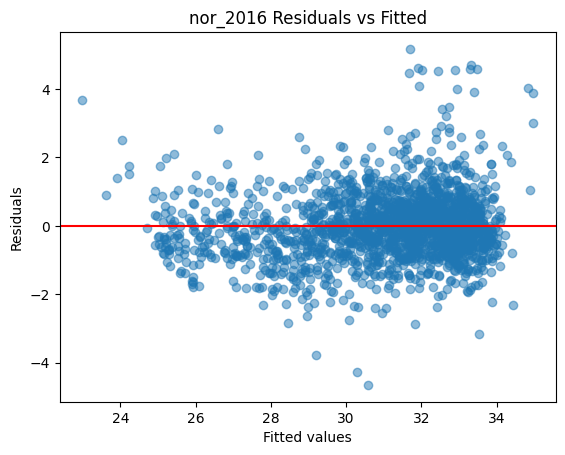

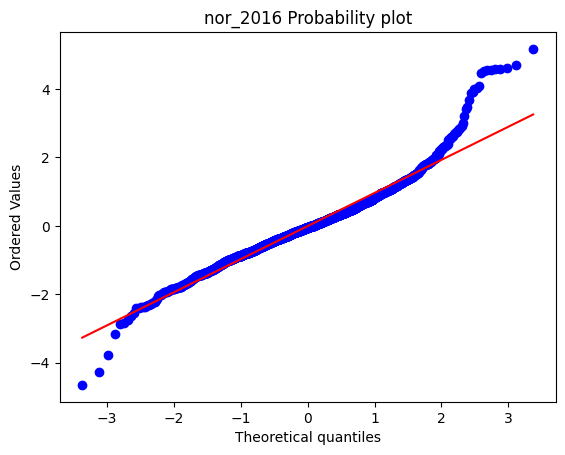

nor_2016 Shapiro-Wilk: stat 0.9578, p-value 0.0000


NameError: name 'model_sdm' is not defined

In [ ]:
from libpysal.weights import DistanceBand, lag_spatial
from spreg import ML_Lag, ML_Error
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from esda.moran import Moran
import warnings
import sys
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
class DummyFile(object):
    def write(self, x): pass
    def flush(self): pass


grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV',
                        'Dist_P', 'Dist_M', 'Dist_W', 'WR']
    explanatory_vars_clean = ['BCR', 'BHV', 'NDVI', 'SVF', 'EV', 'WR']

    results_by_target = {t: [] for t in target_vars}

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'
                yi = data[target].values.reshape(-1, 1)
                x = data[explanatory_vars].values
                name_x = explanatory_vars
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
                model = ML_Error(
                    yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool,
                    name_y=target,
                    name_x=name_x,
                    spat_diag=True
                )

                residuals = model.u  # spreg 里残差是 model.u
                fitted = model.predy.flatten()
                plt.scatter(fitted, residuals, alpha=0.5)
                plt.axhline(0, color='red')
                plt.xlabel("Fitted values")
                plt.ylabel("Residuals")
                plt.title(f"{target} Residuals vs Fitted")
                plt.savefig(os.path.join(grid_folder, rf"statistics\fig\{target} Residuals vs Fitted.png"))
                plt.show()
                residuals = model.u.flatten()   # 变成 (n,)

                stats.probplot(residuals, dist="norm", plot=plt)

                plt.title(f"{target} Probability plot")
                plt.savefig(os.path.join(grid_folder, rf"statistics\fig\{target} Probability plot.png"))
                plt.show()


                residuals = model.u  # spreg 里残差是 model.u
                residuals = model.u.flatten()   # 变成 (n,)
                shapiro_res = stats.shapiro(residuals)
                print(f"{target} Shapiro-Wilk: stat {shapiro_res[0]:.4f}, p-value {shapiro_res[1]:.4f}")
                X_bp = data[explanatory_vars].values
                test = het_breuschpagan(residuals, X_bp)
                print(f"{target} Breusch-Pagan test: F-stat {test[2]:.4f}, p-value {test[3]:.4f}")
                    
                mi = Moran(residuals, w)
                print(f"Moran's I:{mi.I:.4f}", f"p-value: {mi.p_sim:.4f}")

                plt.figure(figsize=(8,5))
                sns.histplot(residuals, bins=30, kde=False, color='skyblue', stat='density', label='Residuals')
                mu, sigma = np.mean(residuals), np.std(residuals)
                x = np.linspace(min(residuals), max(residuals), 100)
                plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Fit')

                plt.title('Residuals Distribution vs Normal Distribution')
                plt.xlabel('Residuals')
                plt.ylabel('Density')
                plt.legend()
                plt.savefig(os.path.join(grid_folder, rf"statistics\fig\{target} Residuals Distribution vs Normal Distribution.png"))
                plt.show()

                # --- Box-Tidwell Test ---
                bt_data = data.copy()
                for col in explanatory_vars:
                    if (bt_data[col] <= 0).any():
                        bt_data[col] = bt_data[col] + abs(bt_data[col].min()) + 1e-6  # 平移

                for col in explanatory_vars:
                    bt_data[f'{col}_ln'] = bt_data[col] * np.log(bt_data[col])

                X_bt = sm.add_constant(bt_data[explanatory_vars + [f'{col}_ln' for col in explanatory_vars]])
                y_bt = bt_data[target]

                bt_model = sm.OLS(y_bt, X_bt).fit()
                print(f"\n===== Box-Tidwell Test for {target} =====")

                for col in explanatory_vars:
                    pval = bt_model.pvalues[f'{col}_ln']
                    if pval < 0.05:
                        print(f"  {col}: Nonlinear relationship detected (p={pval:.4f})")
                    else:
                        print(f"  {col}: Linear relationship acceptable (p={pval:.4f})")

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from esda.moran import Moran
from libpysal.weights import DistanceBand
import scipy.stats as stats

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                y = data[target]
                X = sm.add_constant(data[explanatory_vars])

                # --------- OLS 拟合 ---------
                model = sm.OLS(y, X).fit()
                print(f"\n===== OLS results for {year} | {target} =====")
                print(model.summary())

                residuals = model.resid
                fitted = model.fittedvalues

                # --- 残差 vs 拟合 ---
                plt.scatter(fitted, residuals, alpha=0.5)
                plt.axhline(0, color='red')
                plt.xlabel("Fitted values")
                plt.ylabel("Residuals")
                plt.title(f"{target} Residuals vs Fitted (OLS)")
                plt.savefig(rf"D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\{target}_OLS_residuals_vs_fitted.png")
                plt.close()

                # --- QQ 图 ---
                sm.qqplot(residuals, line="s")
                plt.title(f"{target} QQ Plot (OLS)")
                plt.savefig(rf"D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\{target}_OLS_qqplot.png")
                plt.close()

                # --- Shapiro-Wilk 正态性 ---
                shapiro_res = stats.shapiro(residuals)
                print(f"{target} Shapiro-Wilk: stat {shapiro_res[0]:.4f}, p-value {shapiro_res[1]:.4f}")

                # --- Breusch-Pagan 异方差 ---
                test = het_breuschpagan(residuals, X)
                print(f"{target} Breusch-Pagan: F-stat {test[2]:.4f}, p-value {test[3]:.4f}")

                # --- Moran’s I 检查空间自相关（残差）---
                data_gdf = gdf.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=True)
                w.transform = 'r'
                mi = Moran(residuals.values, w)
                print(f"{target} Moran's I: {mi.I:.4f}, p-value: {mi.p_sim:.4f}")

                # --- 残差分布直方图 vs 正态 ---
                plt.figure(figsize=(8,5))
                sns.histplot(residuals, bins=30, kde=False, color='skyblue', stat='density', label='Residuals')
                mu, sigma = np.mean(residuals), np.std(residuals)
                x = np.linspace(min(residuals), max(residuals), 100)
                plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Fit')
                plt.title(f"{target} Residuals Distribution (OLS)")
                plt.xlabel('Residuals')
                plt.ylabel('Density')
                plt.legend()
                plt.savefig(rf"D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\{target}_OLS_residuals_distribution.png")
                plt.close()


===== OLS results for 2016 | nor_2016 =====
                            OLS Regression Results                            
Dep. Variable:               nor_2016   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     1202.
Date:                Sat, 30 Aug 2025   Prob (F-statistic):               0.00
Time:                        01:01:15   Log-Likelihood:                -2560.1
No. Observations:                1861   AIC:                             5140.
Df Residuals:                    1851   BIC:                             5196.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

# 01 >>>> 最终，我们应该选择SDM! 详细的调试文件在SDM文件中

In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import DistanceBand, lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + [rho_term] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    formula += " + ".join(terms)
    return formula


param_list = []

for year in [2023, 2016]: 

    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 删除 NA
                data = gdf[explanatory_vars + [target]].dropna()
                data_gdf = gdf.loc[data.index]

                # 权重矩阵
                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values

                # SDM slx 变量
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]

                # --- 模型 ---
                model_sdm = ML_Lag(
                    yi, X_main, w=w,
                    slx_lags=1, slx_vars=slx_vars_bool,
                    name_y=target, name_x=explanatory_vars,
                    name_w=f"W{threshold}", name_ds=f"yr{year}",
                    spat_diag=True, spat_impacts=['full']
                )

                # --- 提取系数 ---
                formula_sdm = show_formula(model_sdm, model_type='SDM')
                coef_sdm = dict(zip(model_sdm.name_x, model_sdm.betas.flatten()))

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

# -----------------------------
# 输出
# -----------------------------
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDM_all_params_480m_NOW.xlsx")
all_params_df.to_excel(param_output, index=False)

print("保存完成")

# 02 使用GBDT模型

## 01 GBDT training

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from scipy.stats import randint, uniform, loguniform

# 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
def run_gbdt(grid_folder, years=[2016, 2023], n=0):
    for year in years:
        target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
        explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
        # 保存结果
        all_results = []
        pdp_records = []
        r2_comparison = []

        param_dist = {
            'n_estimators': [4168], #4168
            'learning_rate': loguniform(0.002, 0.355), #(0.002, 0.355)
            'subsample': uniform(0.545, 0.413), # [0.545,0.958]
            'max_depth' : randint(5, 14), # [5, 13]
            'min_samples_split':[2], #2
            'max_features': uniform(0.335, 0.581), #[0.335,0.916]
            }

        # === 主循环 ===
        for filename in os.listdir(grid_folder):
            if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
                input_path = os.path.join(grid_folder, filename)
                match = re.search(r'(\d{3,5})m', filename)
                grid_size = match.group(1)

                gdf = gpd.read_file(input_path)
                gdf_clean = gdf.replace([np.inf, -np.inf], np.nan).dropna(subset=target_vars + explanatory_vars)

                for target in target_vars:
                    X = gdf_clean[explanatory_vars]
                    y = gdf_clean[target]

                    #####################################################################
                    # 用20个 random seeds
                    np.random.seed(0)  # 固定种子以便复现
                    random_seeds = np.random.choice(10000, size=20, replace=False)
                    n = n
                    #####################################################################
                    for r in [random_seeds[n]]:

                        # 数据划分
                        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r) # 切20次

                        gbdt = GradientBoostingRegressor(random_state=0)
                        
                        cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=0)

                        search = RandomizedSearchCV(
                            estimator=gbdt,
                            param_distributions=param_dist,
                            n_iter= 200,
                            scoring='r2',
                            cv=cv, # cross validation
                            verbose=3,
                            n_jobs=-1,
                            random_state=0
                        )

                        search.fit(X_train, y_train)
                        folder = os.path.join(grid_folder, r'Machine Learning')
                        os.makedirs(folder, exist_ok=True)

                        # 先保存一份 checkpoint (CSV，追加方式)
                        checkpoint_path = os.path.join(folder, f"{year}_{target}_seed{n}_checkpoint.csv")
                        df_cv = pd.DataFrame(search.cv_results_)
                        if not os.path.exists(checkpoint_path):
                            df_cv.to_csv(checkpoint_path, index=False)
                        else:
                            df_cv.to_csv(checkpoint_path, mode='a', header=False, index=False)
                        print(f"[SAVE] checkpoint -> {checkpoint_path}")

                        # 再保存原本的 Excel（完整結果）
                        cv_path = os.path.join(folder, f"{n}_{r}_GBDT_{target}_cv_results.xlsx")
                        try:
                            df_cv.to_excel(cv_path, index=False)
                            print(f"[SAVE] CV results -> {cv_path}")
                        except Exception as e:
                            print(f"[ERROR] Save CV results failed: {cv_path} | {e}")
                            raise

                        # 使用测试集评估
                        best_model = search.best_estimator_
                        y_train_pred = best_model.predict(X_train)
                        y_test_pred = best_model.predict(X_test)

                        r2_train = best_model.score(X_train, y_train)
                        r2_test = r2_score(y_test, y_test_pred)

                        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
                        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

                        print(f" {filename} | {target} 最佳参数: {search.best_params_} | R²_train={r2_train:.3f} | R²_test={r2_test:.3f}")

                        for var, importance in zip(explanatory_vars, best_model.feature_importances_):
                            all_results.append({
                                'GridSize': grid_size,
                                'Target': target,
                                'Feature': var,
                                'Random seed':r,
                                'FeatureImportance_TrainModel': round(importance, 4),
                                'Train_R2': round(r2_train, 4),
                                'Train_RMSE': round(rmse_train, 4),
                                'Test_R2': round(r2_test, 4),
                                'Test_RMSE': round(rmse_test, 4),
                                **search.best_params_
                            })
                            r2_comparison.append({
                                'GridSize': grid_size,
                                'Target': target,
                                'Random seed':r,
                                'Train_R2': round(r2_train, 4),
                                'Test_R2': round(r2_test, 4),
                                'Train_RMSE': round(rmse_train, 4),
                                'Test_RMSE': round(rmse_test, 4)
                            })
                

                
                #   保存模型训练后的结果
                df_all = pd.DataFrame(all_results)

                df_all.to_excel(os.path.join(folder, f'{year} GBDT_Random_Search_Results_{n}_{r}.xlsx'), index=False)
                df_r2 = pd.DataFrame(r2_comparison)
                df_r2 = df_r2.sort_values(['Target', 'GridSize'])
                df_r2.to_excel(os.path.join(folder, f'{year} R2_Comparison_Train_vs_Test_{n}_{r}.xlsx'), index=False)
                # print("✅ R² train vs test comparison saved.")

run_gbdt(grid_folder, years=[2016], n=0)

: 

## 02 CV result

In [8]:
import os
import pandas as pd
work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
folder = os.path.join(work_folder, r'16_6387_GBDT_hr_2016_cv_results.xlsx')
file = pd.read_excel(folder)
file

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,23.784171,0.482005,0.037101,0.000746,0.034310,10,0.825518,2,4168,0.899332,"{'learning_rate': 0.034309977022776265, 'max_d...",0.884391,0.914616,0.899971,0.895815,0.888477,0.896654,0.010503,156
1,5.995760,0.078419,0.013763,0.000399,0.160941,8,0.710264,2,4168,0.725724,"{'learning_rate': 0.16094119246640926, 'max_de...",0.894141,0.916981,0.889136,0.898925,0.888019,0.897441,0.010514,148
2,3.519584,0.039658,0.009973,0.000631,0.202677,13,0.493413,2,4168,0.742276,"{'learning_rate': 0.20267695188333315, 'max_de...",0.866631,0.906167,0.886121,0.863471,0.861746,0.876827,0.017070,194
3,4.398234,0.118740,0.011768,0.000746,0.134202,13,0.563208,2,4168,0.890301,"{'learning_rate': 0.13420186966472852, 'max_de...",0.886472,0.905813,0.897297,0.893022,0.888449,0.894211,0.006909,166
4,14.791428,0.084692,0.067619,0.000746,0.011479,9,0.346747,2,4168,0.888872,"{'learning_rate': 0.011478916201752568, 'max_d...",0.893116,0.919409,0.902165,0.897339,0.899121,0.902230,0.009075,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,7.454258,0.034436,0.012370,0.000492,0.314812,5,0.896473,2,4168,0.754653,"{'learning_rate': 0.3148118030349409, 'max_dep...",0.877409,0.895009,0.884258,0.871260,0.858718,0.877331,0.012197,192
196,17.392272,0.055247,0.042087,0.000977,0.009478,7,0.576278,2,4168,0.716646,"{'learning_rate': 0.009477580161406974, 'max_d...",0.904453,0.924052,0.910959,0.906572,0.899662,0.909139,0.008296,27
197,4.147704,0.072353,0.009175,0.000399,0.255663,12,0.844769,2,4168,0.698602,"{'learning_rate': 0.25566286825132806, 'max_de...",0.879177,0.898809,0.887406,0.870629,0.866493,0.880503,0.011647,186
198,15.876675,0.167511,0.045287,0.001748,0.002014,7,0.519894,2,4168,0.899675,"{'learning_rate': 0.0020143801083789686, 'max_...",0.898962,0.922470,0.906530,0.899262,0.902170,0.905879,0.008730,57


In [9]:
import os
import pandas as pd
import numpy as np
from collections import Counter

work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
name = r"GBDT_hr_2016_cv_results.xlsx"
results = []  # 存储所有文件的结果

# 遍历文件夹找目标文件
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)

        # 读入
        df = pd.read_excel(folder)

        # 找最大值对应的行
        best_row = df.loc[df['mean_test_score'].idxmax()]

        prefix = file.split("_GBDT")[0]  # 截取前缀，比如 "15_3184"
        seed_num = int(prefix.split("_")[0])  # 提取前缀里的第一个数字部分

        # 把结果存入列表
        results.append({
            "Seed": seed_num,
            "文件前缀": prefix,
            "最优分数": best_row['mean_test_score'],
            "learning_rate": float(best_row['param_learning_rate']),
            "subsample": float(best_row['param_subsample']),
            "max_depth": int(best_row['param_max_depth']),
            "max_features": float(best_row['param_max_features'])
        })

# 转成 DataFrame
results_df = pd.DataFrame(results)

# 按 Seed 排序
results_df = results_df.sort_values(by="Seed").reset_index(drop=True)

# print("==== 所有结果表格 ====")
print(results_df)

# 每个参数的唯一值统计
print("\n==== 每个参数的唯一值统计 ====")
for col in ["learning_rate", "subsample", "max_depth", "max_features"]:
    counts = results_df[col].value_counts()
    print(f"\n参数 {col}:")
    print(counts)

print("\n==== 每个参数的最高频取值 ====")
top_values = {}
for col in ["learning_rate", "subsample", "max_depth", "max_features"]:
    counts = results_df[col].value_counts()
    top_val = counts.idxmax()   # 出现次数最多的取值
    top_count = counts.max()    # 出现次数
    print(f"参数 {col}: 最常见值 = {top_val}, 出现次数 = {top_count}")
    top_values[col] = (top_val, top_count)
print(top_values)

# 先把最高频参数提取出来
best_params = {
    "param_learning_rate": top_values["learning_rate"][0],
    "param_subsample": top_values["subsample"][0],
    "param_max_depth": top_values["max_depth"][0],
    "param_max_features": top_values["max_features"][0],
}

print("\n==== 使用最高频参数组合查找对应的CV结果 ====")
print(best_params)
scores = []  # 保存 (文件前缀, 分数)

for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)

        # 筛选符合最高频参数组合的行
        mask = (
            (df["param_learning_rate"] == best_params["param_learning_rate"]) &
            (df["param_subsample"] == best_params["param_subsample"]) &
            (df["param_max_depth"] == best_params["param_max_depth"]) &
            (df["param_max_features"] == best_params["param_max_features"])
        )
        match = df.loc[mask]

        if not match.empty:
            mean_score = match["mean_test_score"].values[0]
            prefix = file.split("_GBDT")[0]
            scores.append((prefix, mean_score))
            print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

# 计算平均值
if scores:
    all_scores = [s[1] for s in scores]
    avg_score = sum(all_scores) / len(all_scores)
    print(f"\n平均 mean_test_score = {avg_score}")

    # 找最接近平均值的那个
    closest = min(scores, key=lambda x: abs(x[1] - avg_score))
    print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")


    Seed     文件前缀      最优分数  learning_rate  subsample  max_depth  max_features
0      0   0_9394  0.915352       0.011021   0.565109          5      0.836007
1      1    1_898  0.914877       0.011021   0.565109          5      0.836007
2      2   2_2398  0.920407       0.013651   0.563425          5      0.602176
3      3   3_5906  0.918321       0.013651   0.563425          5      0.602176
4      4   4_2343  0.918828       0.019596   0.557018          5      0.711836
5      5   5_8225  0.912642       0.011021   0.565109          5      0.836007
6      6   6_5506  0.923318       0.013651   0.563425          5      0.602176
7      7   7_6451  0.913466       0.019596   0.557018          5      0.711836
8      8   8_2670  0.916640       0.011021   0.565109          5      0.836007
9      9   9_3497  0.917974       0.013651   0.563425          5      0.602176
10    10  10_1087  0.919884       0.011021   0.565109          5      0.836007
11    11  11_1819  0.916546       0.019596   0.55701

## 1

In [10]:
import os
import pandas as pd

work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
name = r"GBDT_hr_2016_cv_results.xlsx"
results = []  

# 遍历文件夹找目标文件
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)
        best_row = df.loc[df['mean_test_score'].idxmax()]
        prefix = file.split("_GBDT")[0]
        seed_num = int(prefix.split("_")[0])  

        results.append({
            "Seed": seed_num,
            "prefix": prefix,
            "mean_test_score": best_row['mean_test_score'],
            "learning_rate": float(best_row['param_learning_rate']),
            "subsample": float(best_row['param_subsample']),
            "max_depth": int(best_row['param_max_depth']),
            "max_features": float(best_row['param_max_features'],)
        })

# 转成 DataFrame
results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)
print(results_df)
results_df.to_excel(os.path.join(work_folder, 'cv_pairs.xlsx'), index=False)

# === 统计完整组合出现次数 ===
combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
    .value_counts().reset_index(name="count")
print(combo_counts)

# 取出现次数最多的组合
best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
print("\n==== 出现最多的参数组合 ====")
print(best_combo)

# === 用这个组合查找对应的 mean_test_score ===
scores = []
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)
        mask = (
            (df["param_learning_rate"] == best_combo["learning_rate"]) &
            (df["param_subsample"] == best_combo["subsample"]) &
            (df["param_max_depth"] == best_combo["max_depth"]) &
            (df["param_max_features"] == best_combo["max_features"])
        )
        match = df.loc[mask]
        if not match.empty:
            mean_score = match["mean_test_score"].values[0]
            prefix = file.split("_GBDT")[0]
            scores.append((prefix, mean_score))
            print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

# 平均值 + 最接近的结果
if scores:
    all_scores = [s[1] for s in scores]
    avg_score = sum(all_scores) / len(all_scores)
    print(f"\n平均 mean_test_score = {avg_score}")
    closest = min(scores, key=lambda x: abs(x[1] - avg_score))
    print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")


    Seed   prefix  mean_test_score  learning_rate  subsample  max_depth  \
0      0   0_9394         0.915352       0.011021   0.565109          5   
1      1    1_898         0.914877       0.011021   0.565109          5   
2      2   2_2398         0.920407       0.013651   0.563425          5   
3      3   3_5906         0.918321       0.013651   0.563425          5   
4      4   4_2343         0.918828       0.019596   0.557018          5   
5      5   5_8225         0.912642       0.011021   0.565109          5   
6      6   6_5506         0.923318       0.013651   0.563425          5   
7      7   7_6451         0.913466       0.019596   0.557018          5   
8      8   8_2670         0.916640       0.011021   0.565109          5   
9      9   9_3497         0.917974       0.013651   0.563425          5   
10    10  10_1087         0.919884       0.011021   0.565109          5   
11    11  11_1819         0.916546       0.019596   0.557018          5   
12    12  12_2308        

## 2

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial
import os
import pandas as pd



grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
target = 'hr_2016'
print(best_combo)
# 已经固定的最佳参数
best_params = {
    'learning_rate':  best_combo["learning_rate"],
    'max_depth': int(best_combo["max_depth"]),
    'n_estimators': 4168,
    'subsample': best_combo["subsample"],
    'min_samples_split': 2,
    'max_features': best_combo["max_features"],
}
print({k: type(v) for k, v in best_params.items()})

np.random.seed(0)  # 固定种子以便复现
random_seeds = np.random.choice(10000, size=20, replace=False)

years = [2016]
for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

X = gdf_clean[explanatory_vars_gbdt]
y = gdf_clean[target]
# 假设你已有 X, y（特征和目标），只是要划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seeds[9]
)
print(random_seeds[9])
# 定义并训练模型
model = GradientBoostingRegressor(**best_params, random_state=0)
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算指标
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

# 打印结果
print("==== Final Model Performance ====")
print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
# 特征重要性
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": explanatory_vars_gbdt,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n==== Feature Importances ====")
print(feature_importance)

# # 可视化
# plt.figure(figsize=(8, 5))
# plt.barh(feature_importance["Feature"], feature_importance["Importance"])
# plt.gca().invert_yaxis()  # 让最重要的排在最上面
# plt.xlabel("Importance")
# plt.title("Feature Importances (GBDT)")
# plt.tight_layout()
# plt.show()

{'learning_rate': 0.01102140393287835, 'subsample': 0.5651090922378933, 'max_depth': 5.0, 'max_features': 0.8360070757116593}
{'learning_rate': <class 'float'>, 'max_depth': <class 'int'>, 'n_estimators': <class 'int'>, 'subsample': <class 'float'>, 'min_samples_split': <class 'int'>, 'max_features': <class 'float'>}
3497
==== Final Model Performance ====
Train R²: 0.9995, RMSE: 0.0413
Test  R²: 0.9221, RMSE: 0.4931

==== Feature Importances ====
   Feature  Importance
0      BCR    0.490831
3     NDVI    0.158110
10       Y    0.082199
5       WR    0.063542
1      BHV    0.046017
9        X    0.040035
6   Dist_W    0.031759
4       EV    0.027296
2      SVF    0.026160
8   Dist_M    0.018487
7   Dist_P    0.015565


c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 1 + 2 predict models 

In [14]:
# 简化后的找参数 01
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial

all_results = []  # 存所有结果

target_ranges = ['nor_2016','ext_2016','hr_2016']
for target in target_ranges:
    print(target)
    work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
    name = rf"GBDT_{target}_cv_results.xlsx"
    results = []  

    # 遍历文件夹找目标文件
    for file in os.listdir(work_folder):
        if file.endswith(name):
            folder = os.path.join(work_folder, file)
            df = pd.read_excel(folder)
            best_row = df.loc[df['mean_test_score'].idxmax()]
            prefix = file.split("_GBDT")[0]
            seed_num = int(prefix.split("_")[0])  

            results.append({
                "Seed": seed_num,
                "文件前缀": prefix,
                "最优分数": best_row['mean_test_score'],
                "learning_rate": float(best_row['param_learning_rate']),
                "subsample": float(best_row['param_subsample']),
                "max_depth": int(best_row['param_max_depth']),
                "max_features": float(best_row['param_max_features'])
            })

    # 转成 DataFrame
    results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)

    # === 统计完整组合出现次数 ===
    combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
        .value_counts().reset_index(name="count")
    print(combo_counts)

    # 取出现次数最多的组合
    best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
    print("\n==== 出现最多的参数组合 ====")
    print(best_combo)

    # === 用这个组合查找对应的 mean_test_score ===
    scores = []
    for file in os.listdir(work_folder):
        if file.endswith(name):
            folder = os.path.join(work_folder, file)
            df = pd.read_excel(folder)
            mask = (
                (df["param_learning_rate"] == best_combo["learning_rate"]) &
                (df["param_subsample"] == best_combo["subsample"]) &
                (df["param_max_depth"] == best_combo["max_depth"]) &
                (df["param_max_features"] == best_combo["max_features"])
            )
            match = df.loc[mask]
            if not match.empty:
                mean_score = match["mean_test_score"].values[0]
                prefix = file.split("_GBDT")[0]
                scores.append((prefix, mean_score))
                print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

    # 平均值 + 最接近的结果
    if scores:
        all_scores = [s[1] for s in scores]
        avg_score = sum(all_scores) / len(all_scores)
        print(f"\n平均 mean_test_score = {avg_score}")
        closest = min(scores, key=lambda x: abs(x[1] - avg_score))
        print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")
        seed_idx, seed_value = closest[0].split("_")
        seed_idx = int(seed_idx)
        print(f"最接近平均值的文件前缀：{closest[0]} "
            f"(第 {seed_idx} 个 random seed, 值={seed_value}), "
            f"mean_test_score = {closest[1]}")

    ######################################################################
    grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
    explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究

    print(best_combo)
    # 已经固定的最佳参数
    best_params = {
        'learning_rate':  best_combo["learning_rate"],
        'max_depth': int(best_combo["max_depth"]),
        'n_estimators': 4168,
        'subsample': best_combo["subsample"],
        'min_samples_split': 2,
        'max_features': best_combo["max_features"],
    }
    # print({k: type(v) for k, v in best_params.items()})

    np.random.seed(0)  # 固定种子以便复现
    random_seeds = np.random.choice(10000, size=20, replace=False)

    years = [2016]
    for year in years:
        # 清理后的网格数据
        file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
        gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    X = gdf_clean[explanatory_vars_gbdt]
    y = gdf_clean[target]
    # 假设你已有 X, y（特征和目标），只是要划分
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seeds[seed_idx]
    )
    print(random_seeds[9])
    # 定义并训练模型
    model = GradientBoostingRegressor(**best_params, random_state=0)
    model.fit(X_train, y_train)

    # 预测
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 计算指标
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
    test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

    # 打印结果
    print("==== Final Model Performance ====")
    print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    # 特征重要性
    importances = model.feature_importances_
    feature_importance = pd.DataFrame({
        "Feature": explanatory_vars_gbdt,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\n==== Feature Importances ====")
    # print(feature_importance)

    # # 可视化
    # plt.figure(figsize=(8, 5))
    # plt.barh(feature_importance["Feature"], feature_importance["Importance"])
    # plt.gca().invert_yaxis()  # 让最重要的排在最上面
    # plt.xlabel("Importance")
    # plt.title(f"{target} Feature Importances (GBDT)")
    # plt.tight_layout()
    # plt.show()

    ###########################################################################

    # Feature importance 
    importances = model.feature_importances_
    feature_importance = pd.DataFrame({
        "Feature": explanatory_vars_gbdt,
        "FeatureImportance_TrainModel": importances
    })

    # 拼接额外信息
    feature_importance["GridSize"] = 480
    feature_importance["Target"] = target
    feature_importance["Random seed"] = random_seeds[seed_idx]
    feature_importance["Train_R2"] = train_r2
    feature_importance["Train_RMSE"] = train_rmse
    feature_importance["Test_R2"] = test_r2
    feature_importance["Test_RMSE"] = test_rmse
    feature_importance["learning_rate"] = best_params["learning_rate"]
    feature_importance["max_depth"] = best_params["max_depth"]
    feature_importance["max_features"] = best_params["max_features"]
    feature_importance["min_samples_split"] = best_params["min_samples_split"]
    feature_importance["n_estimators"] = best_params["n_estimators"]
    feature_importance["subsample"] = best_params["subsample"]
    feature_importance["CV_mean_test_score "] = avg_score

    # 存入总列表
    all_results.append(feature_importance)

# 合并所有 target 的结果
final_df = pd.concat(all_results, ignore_index=True)

# 打印预览
print(final_df.head())

# 保存到 Excel
final_df.to_excel(r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_summary_results.xlsx", index=False)

   learning_rate  subsample  max_depth  max_features  count
0       0.013651   0.563425          5      0.602176      8
1       0.011021   0.565109          5      0.836007      6
2       0.019596   0.557018          5      0.711836      5
3       0.007906   0.659698          6      0.383288      1

==== 出现最多的参数组合 ====
{'learning_rate': 0.0136505925090242, 'subsample': 0.5634248804179491, 'max_depth': 5.0, 'max_features': 0.6021762684622403}
文件前缀：0_9394, mean_test_score = 0.9153425244410602
文件前缀：10_1087, mean_test_score = 0.9193004248934293
文件前缀：11_1819, mean_test_score = 0.9157003177609218
文件前缀：12_2308, mean_test_score = 0.9230793323131044
文件前缀：13_6084, mean_test_score = 0.9182040460743742
文件前缀：14_3724, mean_test_score = 0.921185545709599
文件前缀：15_3184, mean_test_score = 0.9209445288940945
文件前缀：16_6387, mean_test_score = 0.9155879885895951
文件前缀：17_3728, mean_test_score = 0.9200370035533029
文件前缀：18_2702, mean_test_score = 0.9201061537709444
文件前缀：19_7883, mean_test_score = 0.921767163582

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


==== Final Model Performance ====
Train R²: 0.9997, RMSE: 0.0455
Test  R²: 0.9309, RMSE: 0.6333

==== Feature Importances ====
   learning_rate  subsample  max_depth  max_features  count
0       0.013651   0.563425          5      0.602176     11
1       0.011021   0.565109          5      0.836007      5
2       0.019596   0.557018          5      0.711836      3
3       0.005067   0.637481          5      0.796138      1

==== 出现最多的参数组合 ====
{'learning_rate': 0.0136505925090242, 'subsample': 0.5634248804179491, 'max_depth': 5.0, 'max_features': 0.6021762684622403}
文件前缀：0_9394, mean_test_score = 0.9458741335213829
文件前缀：10_1087, mean_test_score = 0.9493396252865413
文件前缀：11_1819, mean_test_score = 0.9465680402323029
文件前缀：12_2308, mean_test_score = 0.9501616552007057
文件前缀：13_6084, mean_test_score = 0.9475095098660254
文件前缀：14_3724, mean_test_score = 0.9486634161837533
文件前缀：15_3184, mean_test_score = 0.9500057555175317
文件前缀：16_6387, mean_test_score = 0.947267488987577
文件前缀：17_3728, mean_te

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


==== Final Model Performance ====
Train R²: 0.9998, RMSE: 0.0557
Test  R²: 0.9554, RMSE: 0.8861

==== Feature Importances ====
   learning_rate  subsample  max_depth  max_features  count
0       0.011021   0.565109          5      0.836007      9
1       0.013651   0.563425          5      0.602176      7
2       0.019596   0.557018          5      0.711836      3
3       0.007906   0.659698          6      0.383288      1

==== 出现最多的参数组合 ====
{'learning_rate': 0.01102140393287835, 'subsample': 0.5651090922378933, 'max_depth': 5.0, 'max_features': 0.8360070757116593}
文件前缀：0_9394, mean_test_score = 0.9153524020986762
文件前缀：10_1087, mean_test_score = 0.919883984823809
文件前缀：11_1819, mean_test_score = 0.9163635546121416
文件前缀：12_2308, mean_test_score = 0.9170284143419674
文件前缀：13_6084, mean_test_score = 0.9162850350251949
文件前缀：14_3724, mean_test_score = 0.9171177240565356
文件前缀：15_3184, mean_test_score = 0.9174654138228094
文件前缀：16_6387, mean_test_score = 0.9120335045185349
文件前缀：17_3728, mean_t

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 3 feature importance

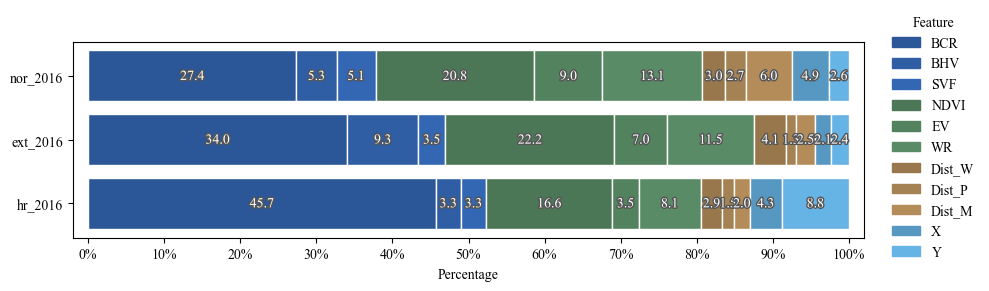

Saved to: D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_feature_importance_stacked.png


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
path = r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_summary_results.xlsx"
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)

# 归一化（每个 target 的行和为 1）
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

# 手动调整 Target 的行顺序
row_order = ['hr_2016', 'ext_2016','nor_2016']
pivot_norm = pivot_norm.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot_norm))))
bottom = np.zeros(len(pivot_norm))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot_norm[feature].values
    ax.barh(pivot_norm.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")
# ax.set_ylabel("Target")
# ax.set_title("Feature importance proportions per Target")

plt.tight_layout()
# 保存到本地（示例）
out_file = r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_feature_importance_stacked.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

## 4. 出一下不同的seed的PDP 值

In [ ]:
from sklearn.model_selection import train_test_split
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

# ----------------- 配置 -----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = os.path.join(grid_folder, 'Machine Learning', 'figures', 'pdp_direct_plot')
os.makedirs(output_fig_dir, exist_ok=True)


explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
years = [2016]
top_n_features = 9  # PDP 提取 top N 变量

# ----------------- 主循环 -----------------
for year in years:
    file = fr'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file)
    
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\cv_pairs.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)

    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)

    # --- 目标变量分组 ---
    targets = 'hr_2016'

    for feature in explanatory_vars:
        # 建一张图
        fig, ax = plt.subplots(figsize=(8,5))

        for seed in range(20):
            row_gbdt = best_df_gbdt[best_df_gbdt['Seed'] == seed].iloc[0]
            params_gbdt = {
                'learning_rate': row_gbdt['learning_rate'],
                'max_depth': int(row_gbdt['max_depth']),
                'n_estimators': 4168,
                'subsample': row_gbdt['subsample'],
                'min_samples_split': 2,
                'max_features': float(row_gbdt['max_features']),
                'random_state': 0
            }

            X = gdf_clean[explanatory_vars_gbdt]
            y = gdf_clean[targets]   # 注意这里应该是 targets 而不是 target
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2,
                random_state=int(str(row_gbdt["prefix"]).split("_")[1])
            )
            model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

            # ----------- PDP 计算部分 -----------

            X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
            X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
            X_base[feature] = X_grid

            y_gbdt_pred = model.predict(X_base)

            for x in X[feature]:
                plt.axvline(x=x, color='gray', alpha=0.1, linewidth=0.1)
            if seed == 9:
                ax.plot(X_grid, y_gbdt_pred, linewidth=2.5, color="red", 
                        label="The final nonlinear curve", zorder=10)
            else:
                ax.plot(X_grid, y_gbdt_pred, linewidth=1, color="gray", alpha=0.5, zorder=1)


        # 设置全局字体为 Times New Roman
        plt.rcParams["font.family"] = "Times New Roman"
        plt.xlabel(feature, fontsize=16)
        plt.ylabel('Temperature (℃)', fontsize=16)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(False)
        ax.legend()
        ax.set_ylim(-20, 0)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f'Seed_PDP_{feature}_hr.jpg'), dpi=300)
        plt.close(fig)


## 出一下不同的seed的预测值

In [ ]:
# ==== 最终版：20 seeds 结果输出 ====
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ---------------- 配置 ----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
work_folder = os.path.join(grid_folder, "Machine Learning")
cv_file = "cv_pairs.xlsx"   # 你的CV结果文件
output_file = os.path.join(work_folder, "final_GBDT_summary_results_20seeds.xlsx")

explanatory_vars_gbdt = ['BCR','BHV','SVF','NDVI','EV','WR','Dist_W','Dist_P','Dist_M','X','Y']
target_ranges = ['nor_2016','ext_2016','hr_2016']
years = [2016]

all_results = []  # 存所有结果

# ---------------- 主循环 ----------------
for target in target_ranges:
    print(f"\n==== Target: {target} ====")

    # 1) 收集CV结果（找最常见参数组合）
    results = []
    for file in os.listdir(work_folder):
        if file.endswith(cv_file):
            df = pd.read_excel(os.path.join(work_folder, file))
            best_row = df.loc[df['mean_test_score'].idxmax()]
            prefix = file.split("_GBDT")[0]
            seed_num = int(prefix.split("_")[0])

            results.append({
                "Seed": seed_num,
                "prefix": prefix,
                "mean_test_score": best_row['mean_test_score'],
                "learning_rate": float(best_row['param_learning_rate']),
                "subsample": float(best_row['param_subsample']),
                "max_depth": int(best_row['param_max_depth']),
                "max_features": float(best_row['param_max_features'])
            })

    results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)

    # 统计完整组合出现次数
    combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
        .value_counts().reset_index(name="count")
    print("参数组合频率：\n", combo_counts)

    # 取出现次数最多的组合
    best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
    print("最常见参数组合：", best_combo)

    # 用这个组合查找对应的 mean_test_score
    scores = []
    for file in os.listdir(work_folder):
        if file.endswith(cv_file):
            df = pd.read_excel(os.path.join(work_folder, file))
            mask = (
                (df["param_learning_rate"] == best_combo["learning_rate"]) &
                (df["param_subsample"] == best_combo["subsample"]) &
                (df["param_max_depth"] == best_combo["max_depth"]) &
                (df["param_max_features"] == best_combo["max_features"])
            )
            match = df.loc[mask]
            if not match.empty:
                mean_score = match["mean_test_score"].values[0]
                prefix = file.split("_GBDT")[0]
                scores.append((prefix, mean_score))

    avg_score = np.mean([s[1] for s in scores]) if scores else np.nan
    print(f"CV 平均 mean_test_score = {avg_score:.6f}")

    # 2) 固定参数
    best_params = {
        'learning_rate':  best_combo["learning_rate"],
        'max_depth': int(best_combo["max_depth"]),
        'n_estimators': 4168,
        'subsample': best_combo["subsample"],
        'min_samples_split': 2,
        'max_features': best_combo["max_features"],
    }

    # 3) 遍历 20 个随机种子
    np.random.seed(0)
    random_seeds = np.random.choice(10000, size=20, replace=False)

    for year in years:
        file = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    X = gdf_clean[explanatory_vars_gbdt]
    y = gdf_clean[target]

    for seed in random_seeds:
        # 划分训练测试
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

        # 训练模型
        model = GradientBoostingRegressor(**best_params, random_state=seed)
        model.fit(X_train, y_train)

        # 预测 & 指标
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

        # 特征重要性
        feature_importance = pd.DataFrame({
            "Feature": explanatory_vars_gbdt,
            "FeatureImportance_TrainModel": model.feature_importances_
        })

        # 拼接额外信息
        feature_importance["GridSize"] = 480
        feature_importance["Target"] = target
        feature_importance["Random seed"] = seed
        feature_importance["Train_R2"] = train_r2
        feature_importance["Train_RMSE"] = train_rmse
        feature_importance["Test_R2"] = test_r2
        feature_importance["Test_RMSE"] = test_rmse
        feature_importance["learning_rate"] = best_params["learning_rate"]
        feature_importance["max_depth"] = best_params["max_depth"]
        feature_importance["max_features"] = best_params["max_features"]
        feature_importance["min_samples_split"] = best_params["min_samples_split"]
        feature_importance["n_estimators"] = best_params["n_estimators"]
        feature_importance["subsample"] = best_params["subsample"]
        feature_importance["CV_mean_test_score"] = avg_score  # 这里存CV均值

        all_results.append(feature_importance)

# ---------------- 保存结果 ----------------
final_df = pd.concat(all_results, ignore_index=True)
print(final_df.head())

final_df.to_excel(output_file, index=False)
print(f"\n✅ 已保存到 {output_file}")
